In [ ]:
# # CS3807 – Deep Learning Laboratory
# ## Experiment 4: Comparative Study of Deep CNN Architectures Using Transfer Learning (CIFAR-10)
#
# **This notebook follows the lab manual exactly as written**, with no additions beyond it:
# MobileNetV2 as the pretrained backbone, native $32\times32$ input (no resizing), and Task 4
# fine-tuning implemented literally as stated ("unfreeze the last convolution block") without any
# extra BatchNorm handling, data augmentation, or training callbacks that the manual doesn't
# mention.
#
# **Formatting still follows CS3807 conventions:** Times New Roman, 600 dpi, EPS exports.
#
# > Reminder: perform and debug independently; use this as a reference to study, not to submit as-is.
#
# > **Tip:** Runtime → Change runtime type → GPU (T4).
#
#
# ## 0. Setup — Fonts, Imports, Plot Configuration

# ===== CELL 1: Install Times New Roman (for 600 dpi / EPS figures) =====
!apt-get -qq update > /dev/null 2>&1
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get -qq install -y ttf-mscorefonts-installer > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1
!fc-list | grep -i "times new roman" || echo "NOT FOUND - will need Runtime > Restart session and rerun"


/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf: Times New Roman:style=Regular,Normal,obyčejné,Standard,Κανονικά,Normaali,Normál,Normale,Standaard,Normalny,Обычный,Normálne,Navadno,thường,Arrunta
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf: Times New Roman:style=Italic,cursiva,kurzíva,kursiv,Πλάγια,Kursivoitu,Italique,Dőlt,Corsivo,Cursief,kursywa,Itálico,Курсив,İtalik,Poševno,nghiêng,Etzana
/usr/share/fonts/truetype/msttcorefonts/timesbd.ttf: Times New Roman:style=Bold,Negreta,tučné,fed,Fett,Έντονα,Negrita,Lihavoitu,Gras,Félkövér,Grassetto,Vet,Halvfet,Pogrubiona,Negrito,Полужирный,Fet,Kalın,Krepko,đậm,Lodia
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf: Times New Roman:style=Bold Italic,Negreta cursiva,tučné kurzíva,fed kursiv,Fett Kursiv,Έντονα Πλάγια,Negrita Cursiva,Lihavoitu Kursivoi,Gras Italique,Félkövér dőlt,Grassetto Corsivo,Vet Cursief,Halvfet Kursiv,Pogrubiona kursywa,Negrito Itálico,Полужирный Курсив,Tučná kurzíva

In [ ]:
# ===== CELL 1b: Fallback font download =====
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf


In [ ]:
!pip install -q tensorflow scikit-learn seaborn matplotlib


In [ ]:
# ===== CELL 2: Imports, font config, plot/save configuration =====
import os
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
)

for f in os.listdir(matplotlib.get_cachedir()):
    if 'fontlist' in f:
        os.remove(os.path.join(matplotlib.get_cachedir(), f))
fm.fontManager = fm.FontManager()

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    """Save a figure at 600 dpi in EPS format, per CS3807 lab conventions."""
    path = os.path.join(PLOT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

print("Configured font.serif priority:", plt.rcParams['font.serif'][:3])

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Configured font.serif priority: ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif']
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ## Task 1: Dataset Preparation
# 1. Load CIFAR-10.
# 2. Normalize pixel values to [0,1].
# 3. Display ten sample images.
# 4. Print training/testing set dimensions.

# ===== CELL 3: Load, normalize to [0,1], inspect =====
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Train set : {x_train.shape}, labels {y_train.shape}")
print(f"Test set  : {x_test.shape}, labels {y_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1833s 11us/step
Train set : (50000, 32, 32, 3), labels (50000, 1)
Test set  : (10000, 32, 32, 3), labels (10000, 1)


Saved: /content/plots/01_sample_images.eps


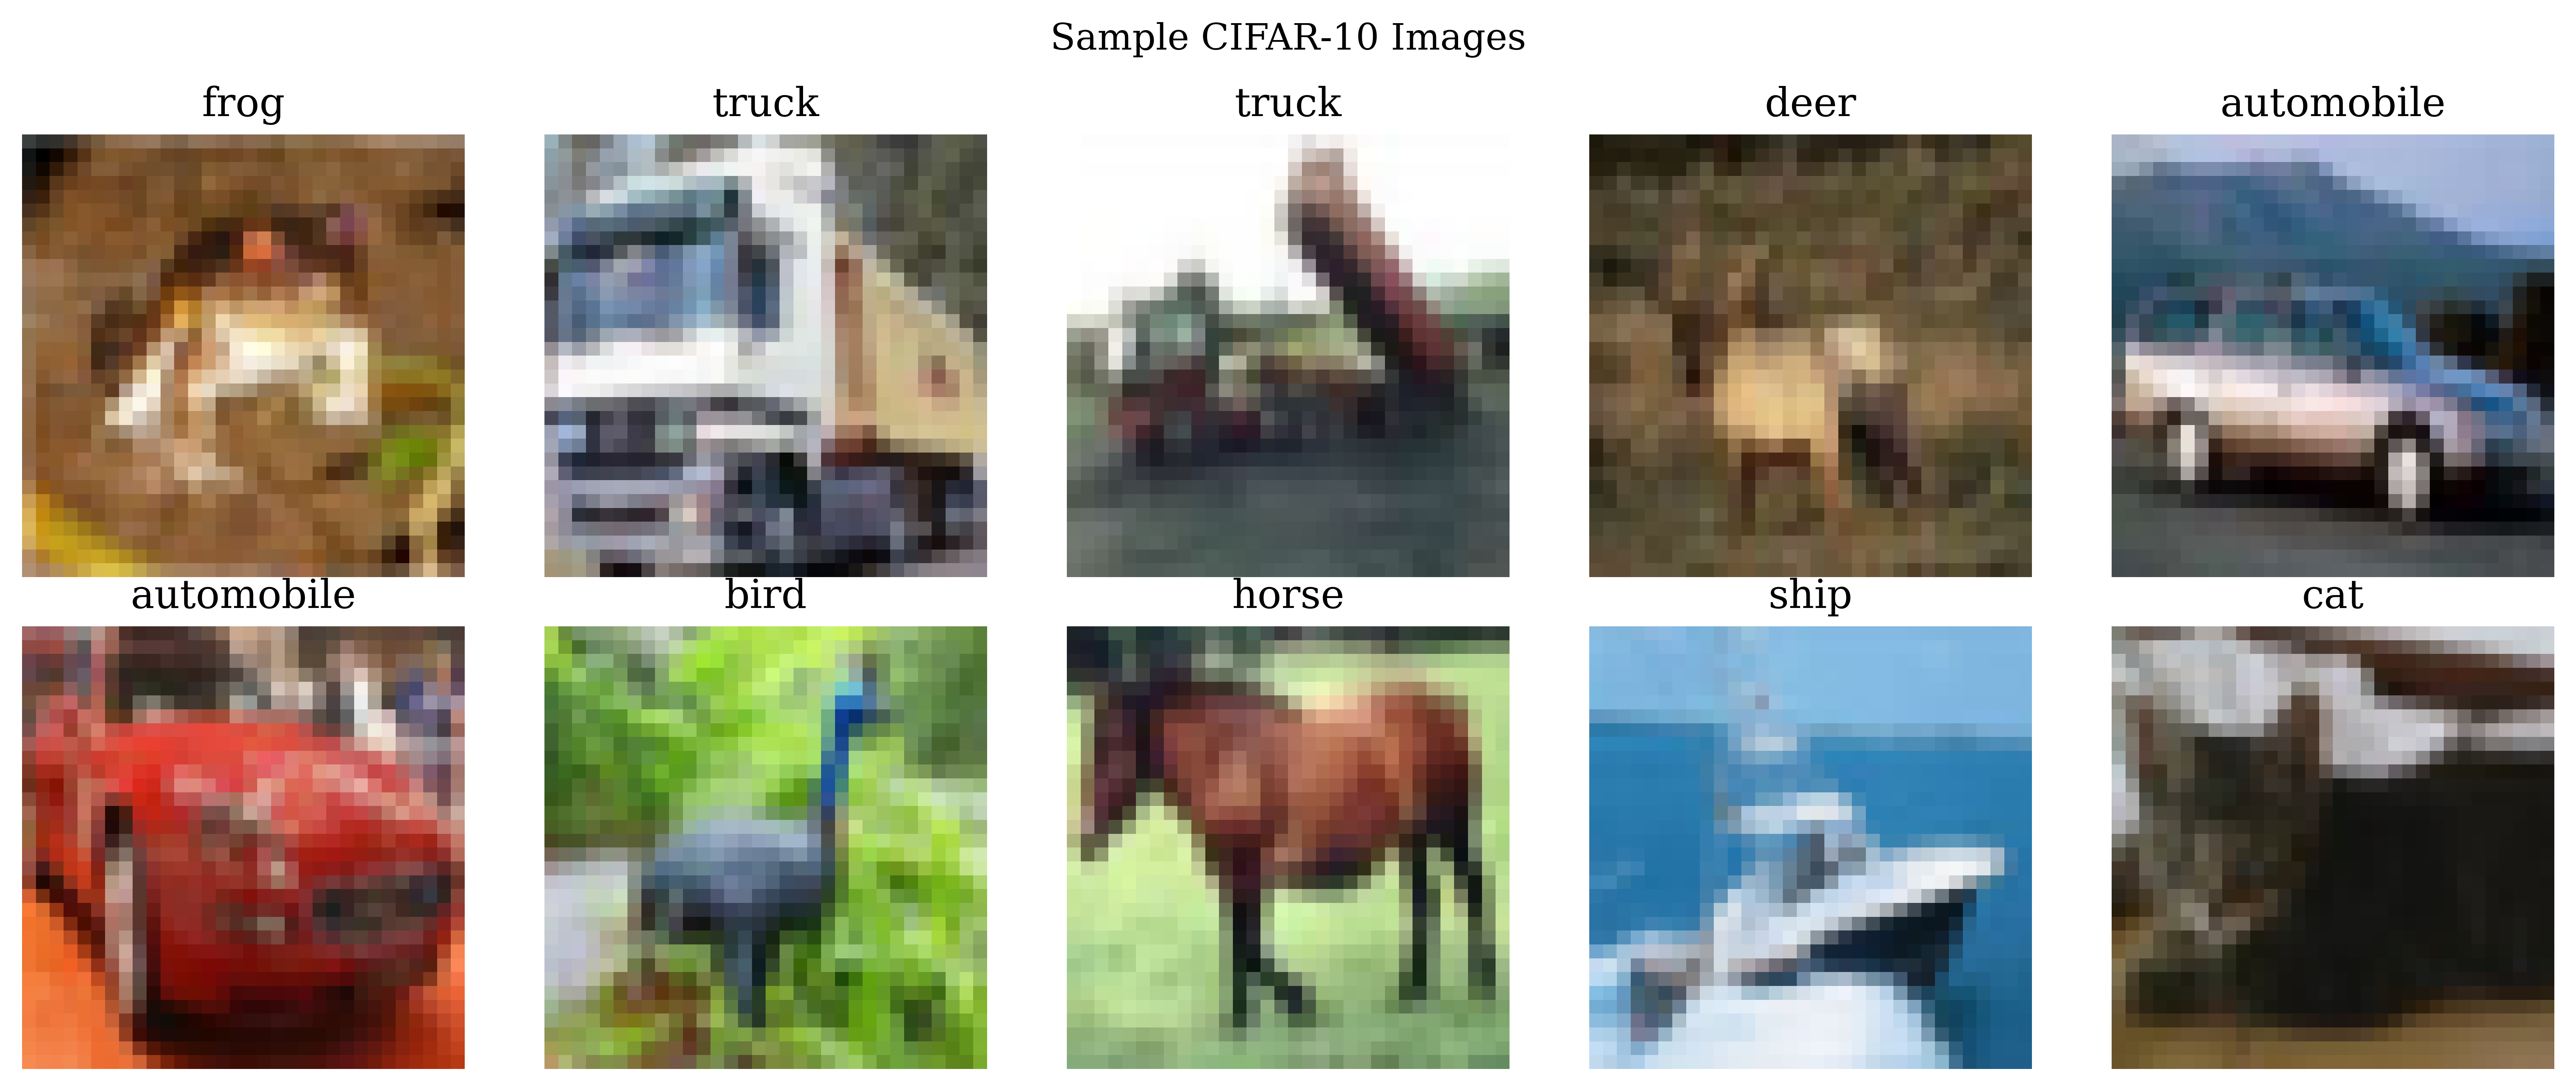

In [ ]:
# ===== CELL 4: Ten sample images (Mandatory Plot 1) =====
def plot_sample_images(x, y, filename, n=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i])
        ax.set_title(CLASS_NAMES[int(y[i])])
        ax.axis("off")
    fig.suptitle("Sample CIFAR-10 Images")
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

plot_sample_images(x_train, y_train.flatten(), "01_sample_images")


In [ ]:
# ## Task 2: Transfer Learning
#
# 1. Load pretrained ImageNet weights (MobileNetV2).
# 2. Remove the original classification layer (`include_top=False`).
# 3. Freeze the convolutional base.
# 4. Add a Global Average Pooling layer.
# 5. Add a Dense layer with ReLU activation.
# 6. Add the output layer with Softmax activation.

# ===== CELL 5: Build the MobileNetV2 transfer-learning model =====
base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


/tmp/ipykernel_1005/1412071561.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ===== CELL 6: Total Parameters (needed for Results Table 18.1) =====
total_params = model.count_params()
trainable_params = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {int(trainable_params):,}")
print(f"Non-trainable parameters: {total_params - int(trainable_params):,}")


Total parameters: 2,423,242
Trainable parameters: 165,258
Non-trainable parameters: 2,257,984


In [ ]:
# ## Task 3: Model Training
#
# Optimizer: Adam | Learning Rate: 0.001 | Batch Size: 32 | Epochs: 10-20 |
# Loss: Categorical Cross Entropy | Metric: Accuracy

# ===== CELL 7: Train (frozen base) =====
t0 = time.time()
history_frozen = model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    batch_size=32,
    epochs=15,
)
frozen_train_time = time.time() - t0

test_loss_frozen, test_acc_frozen = model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Frozen-base test accuracy: {test_acc_frozen:.4f}")


Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.2978 - loss: 1.9385 - val_accuracy: 0.3372 - val_loss: 1.8436
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3333 - loss: 1.8366 - val_accuracy: 0.3488 - val_loss: 1.8081
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3471 - loss: 1.7982 - val_accuracy: 0.3536 - val_loss: 1.7898
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3580 - loss: 1.7709 - val_accuracy: 0.3564 - val_loss: 1.7783
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3664 - loss: 1.7486 - val_accuracy: 0.3616 - val_loss: 1.7720
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3731 - loss: 1.7296 - val_accuracy: 0.3638 - val_loss: 1.7682
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3790 - loss: 1.7129 - val_accuracy: 0.3628 - val_loss: 1.7669
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3837 - loss: 1

Saved: /content/plots/02_training_accuracy.eps


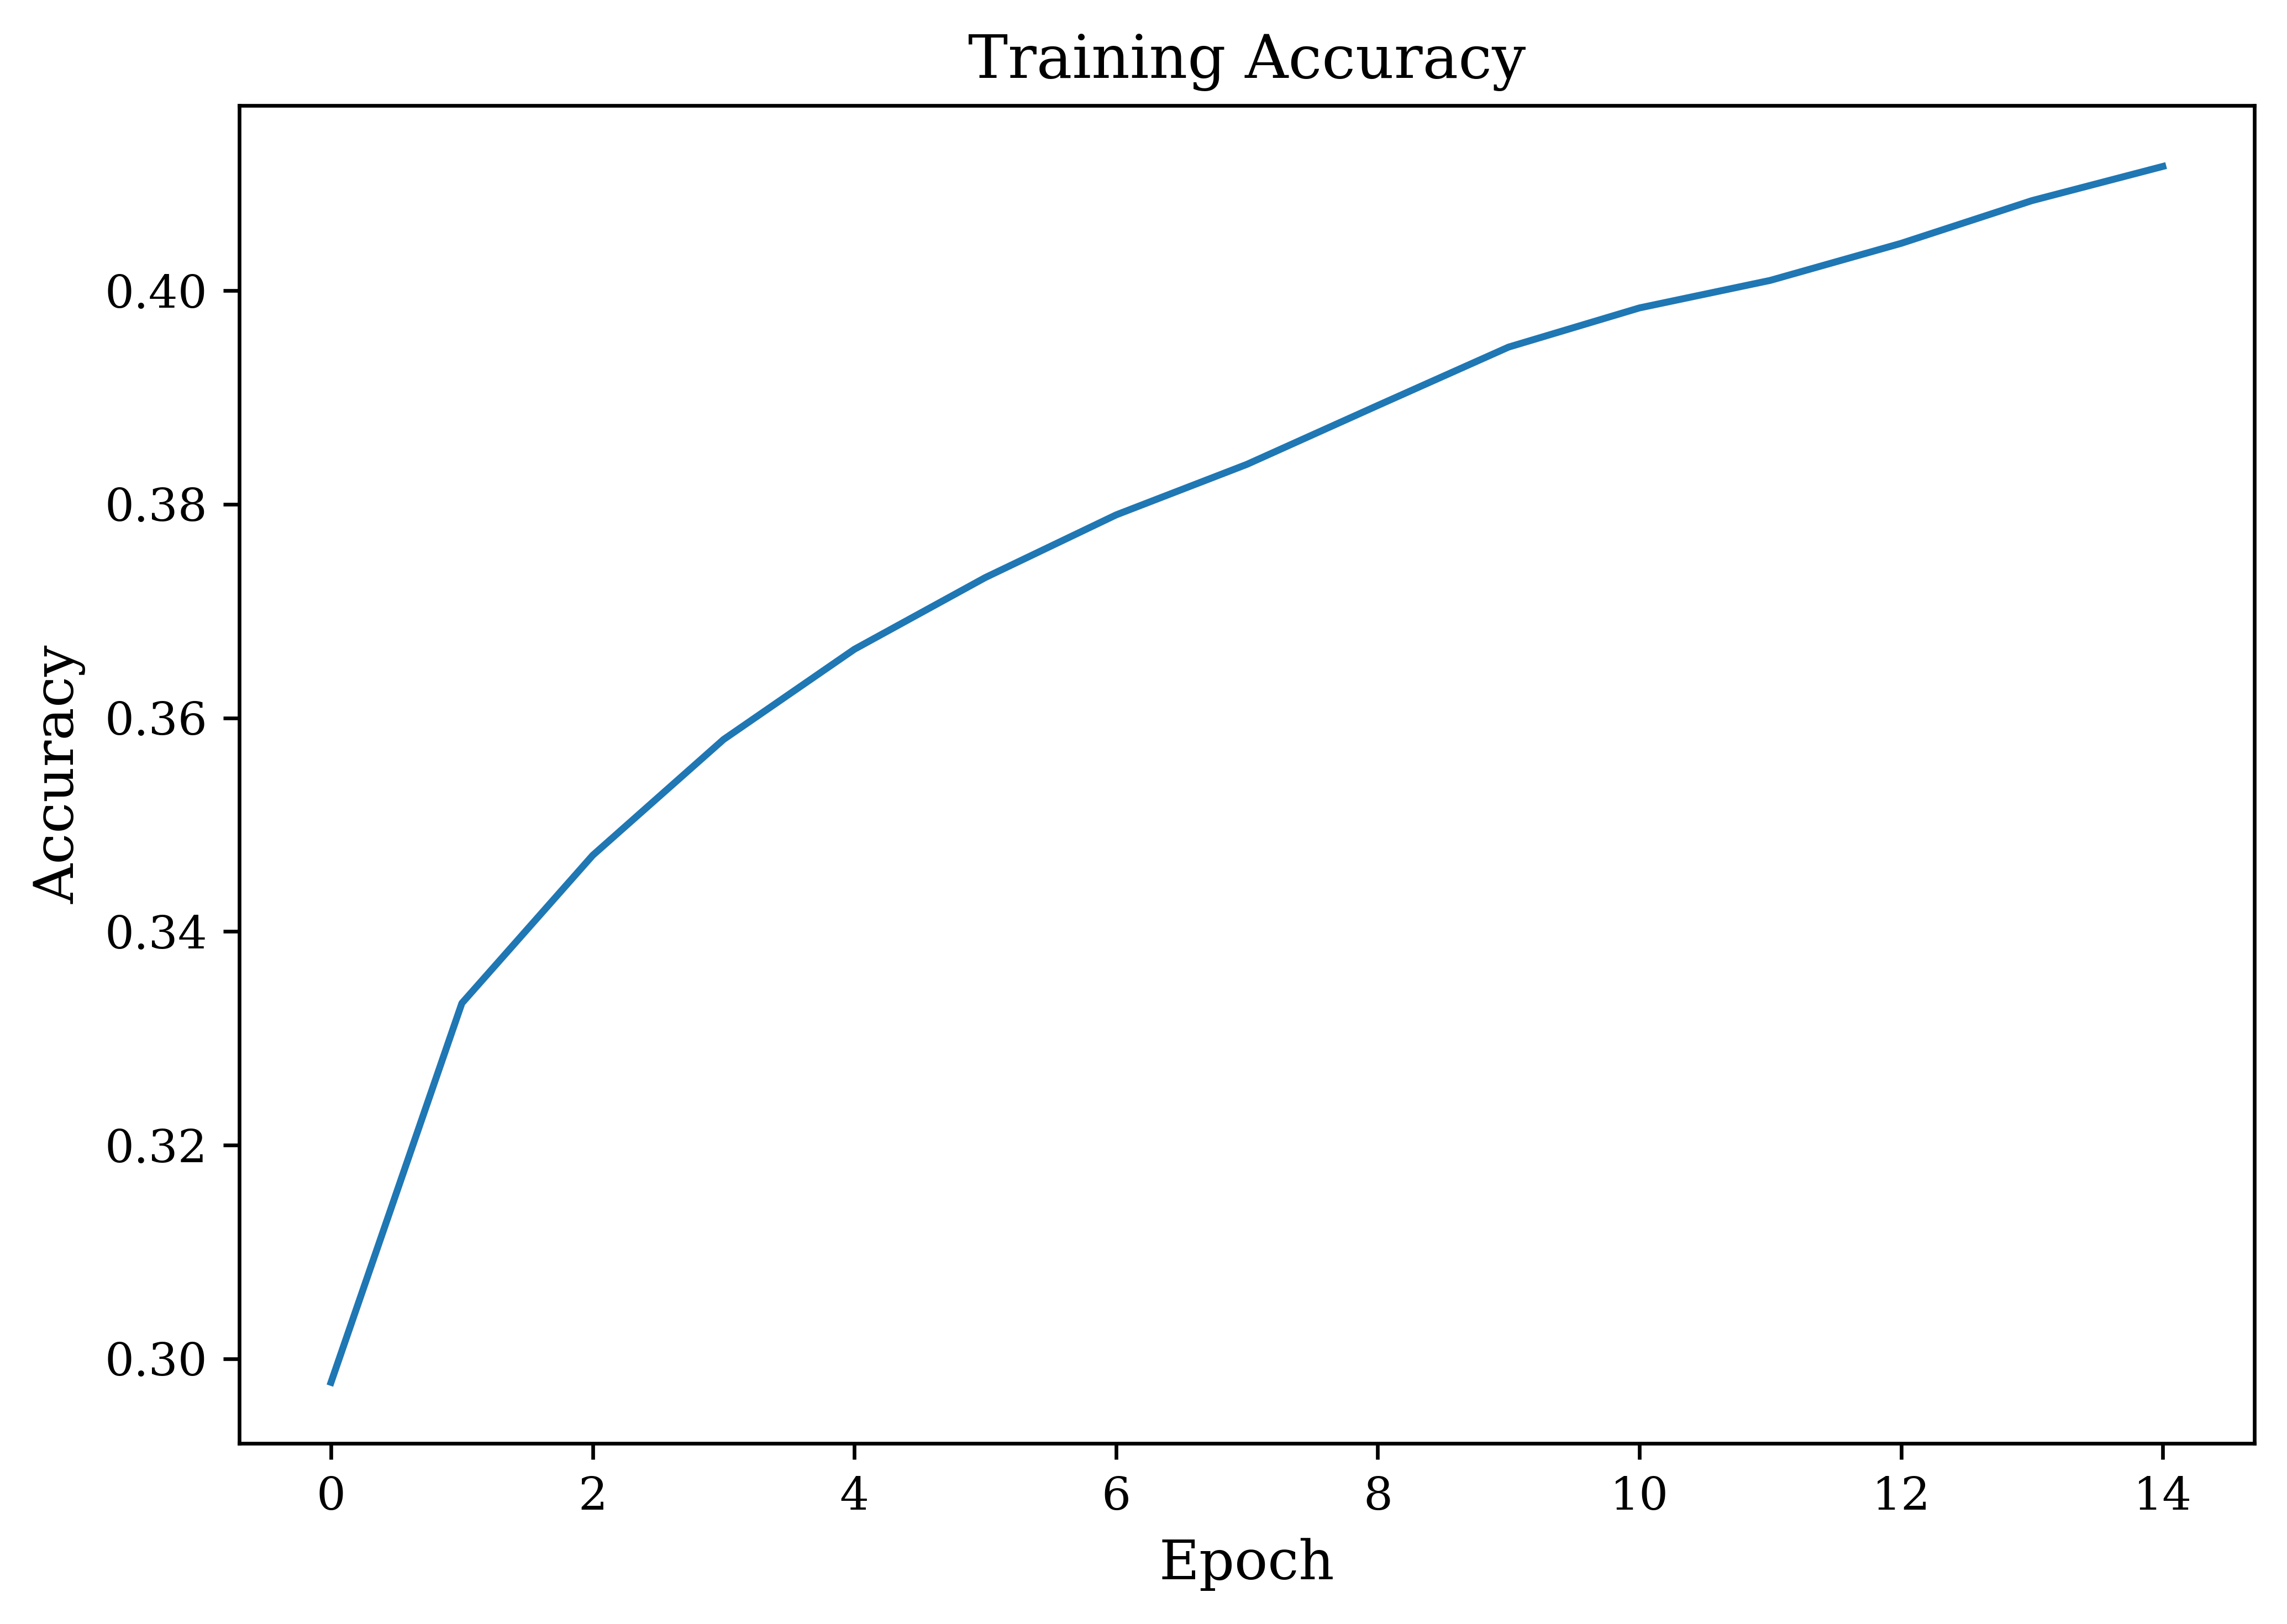

Saved: /content/plots/03_validation_accuracy.eps


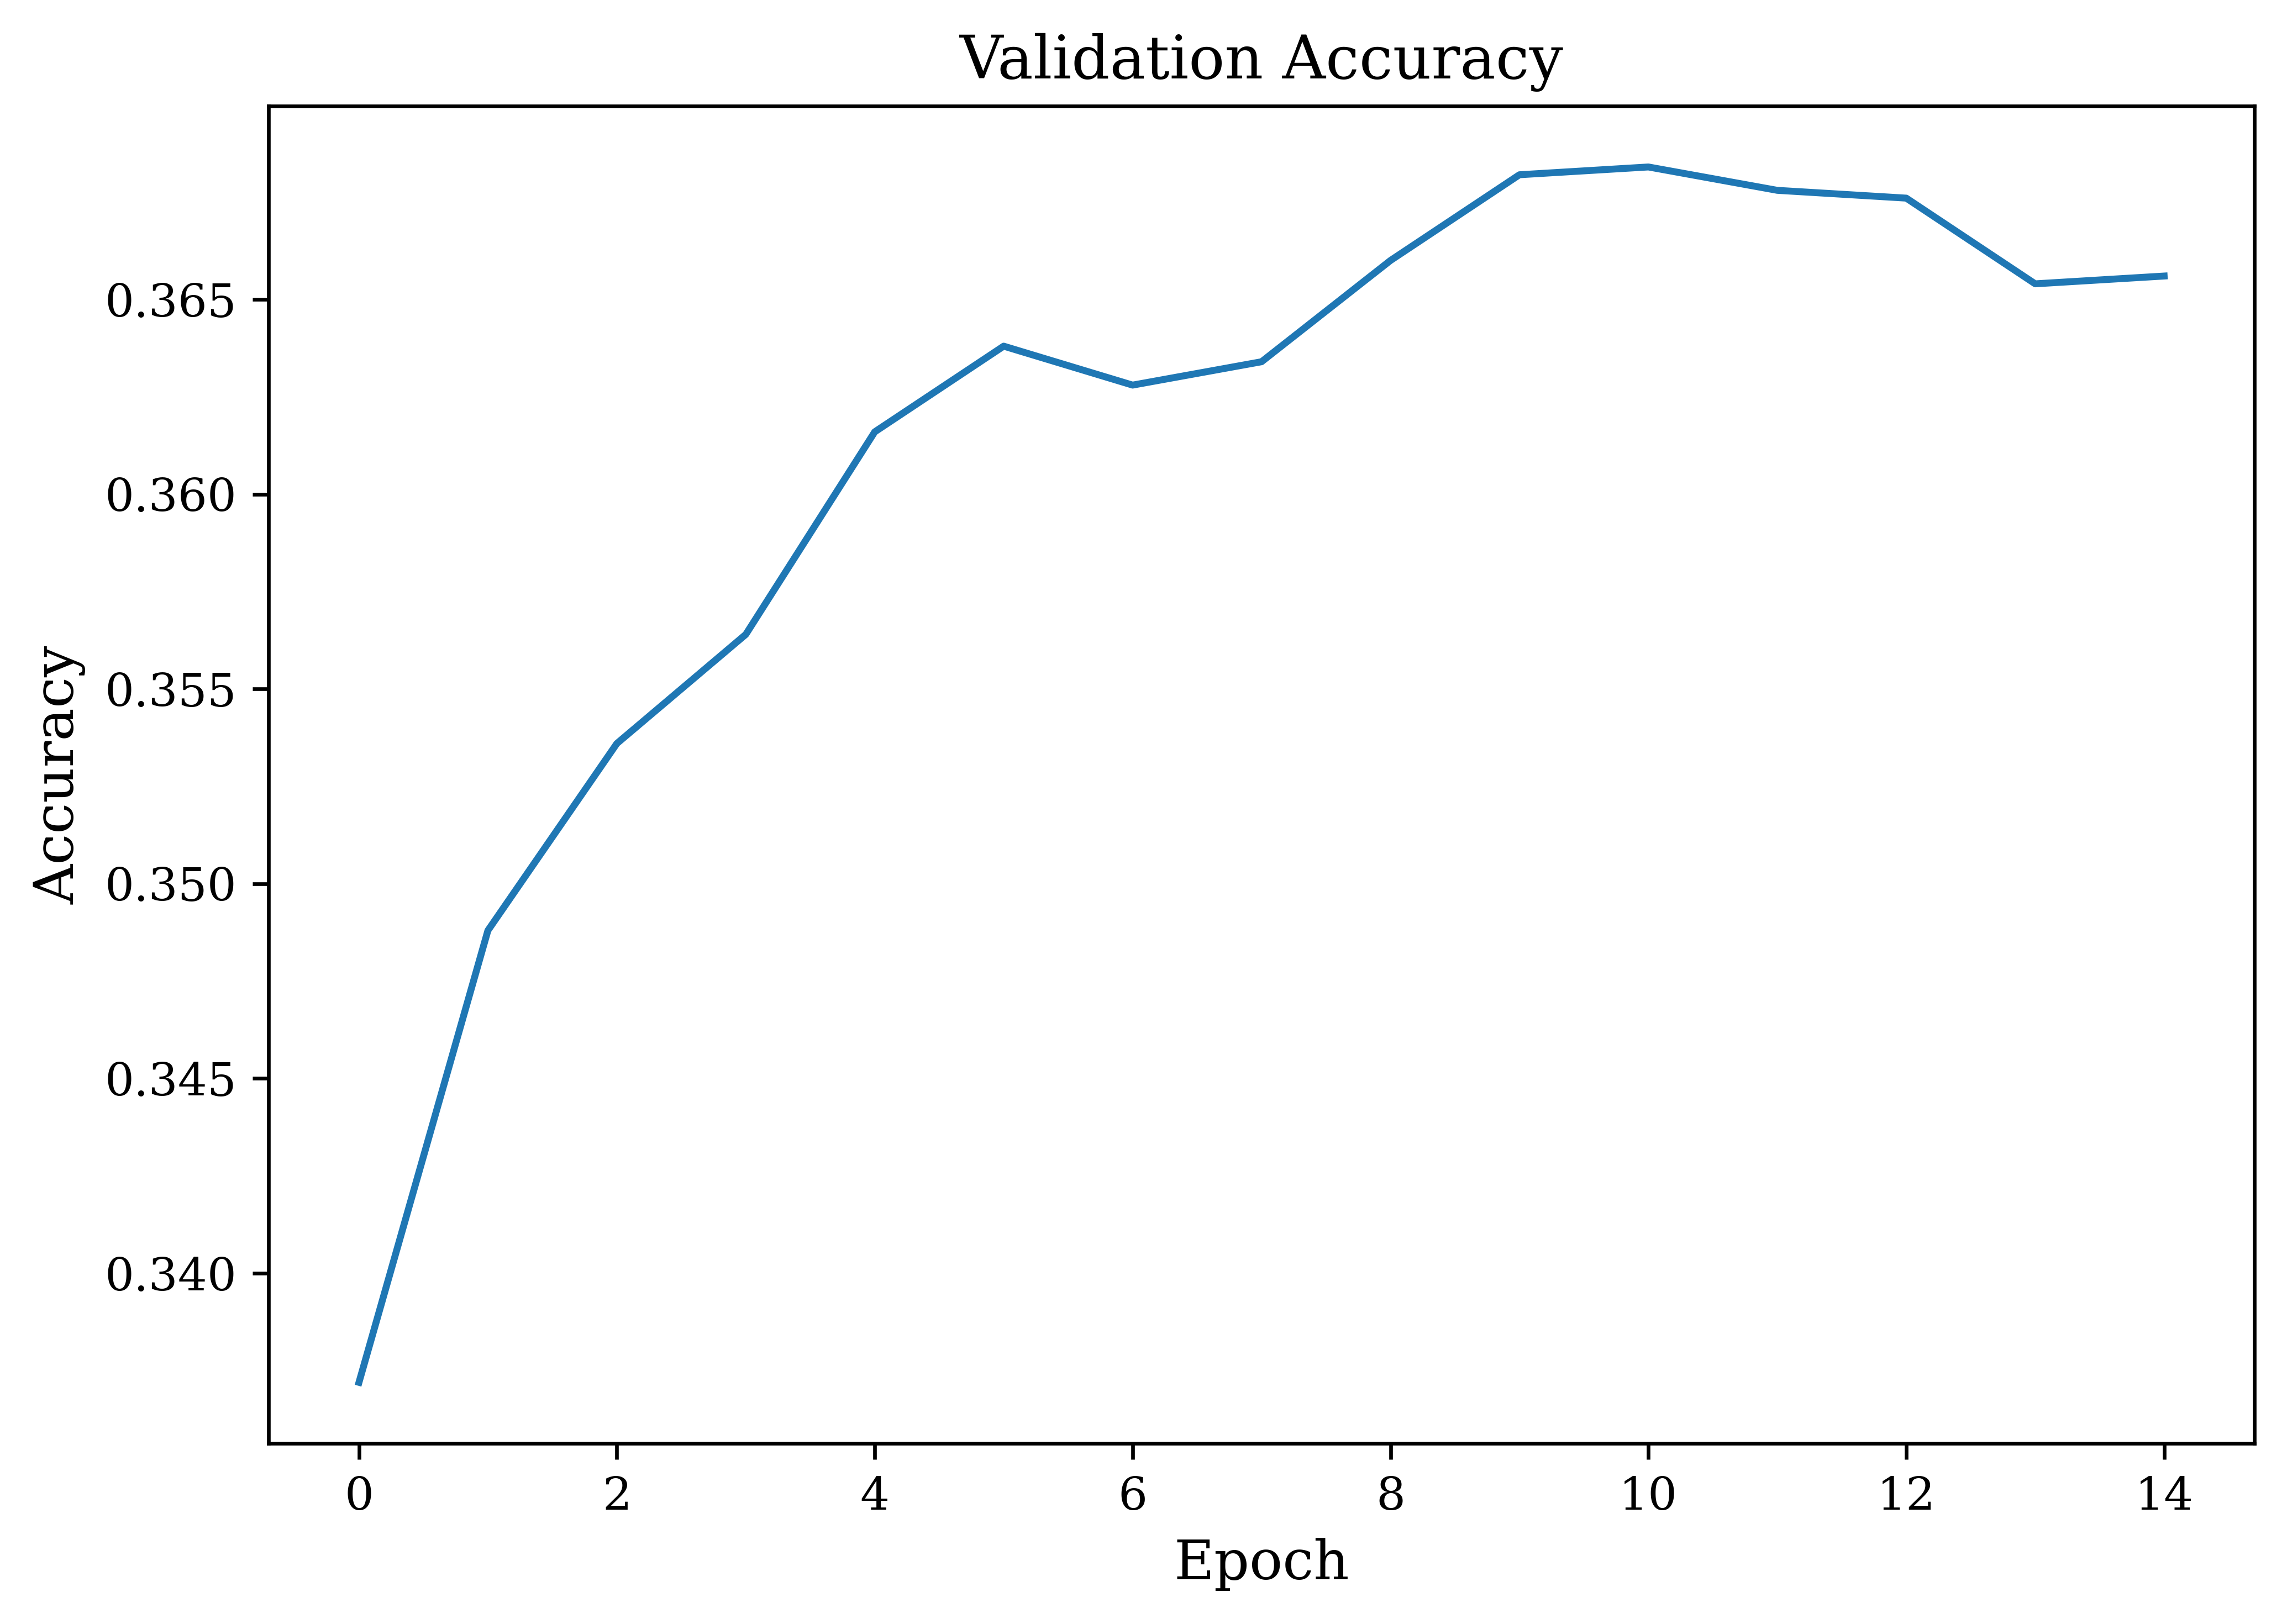

Saved: /content/plots/04_training_loss.eps


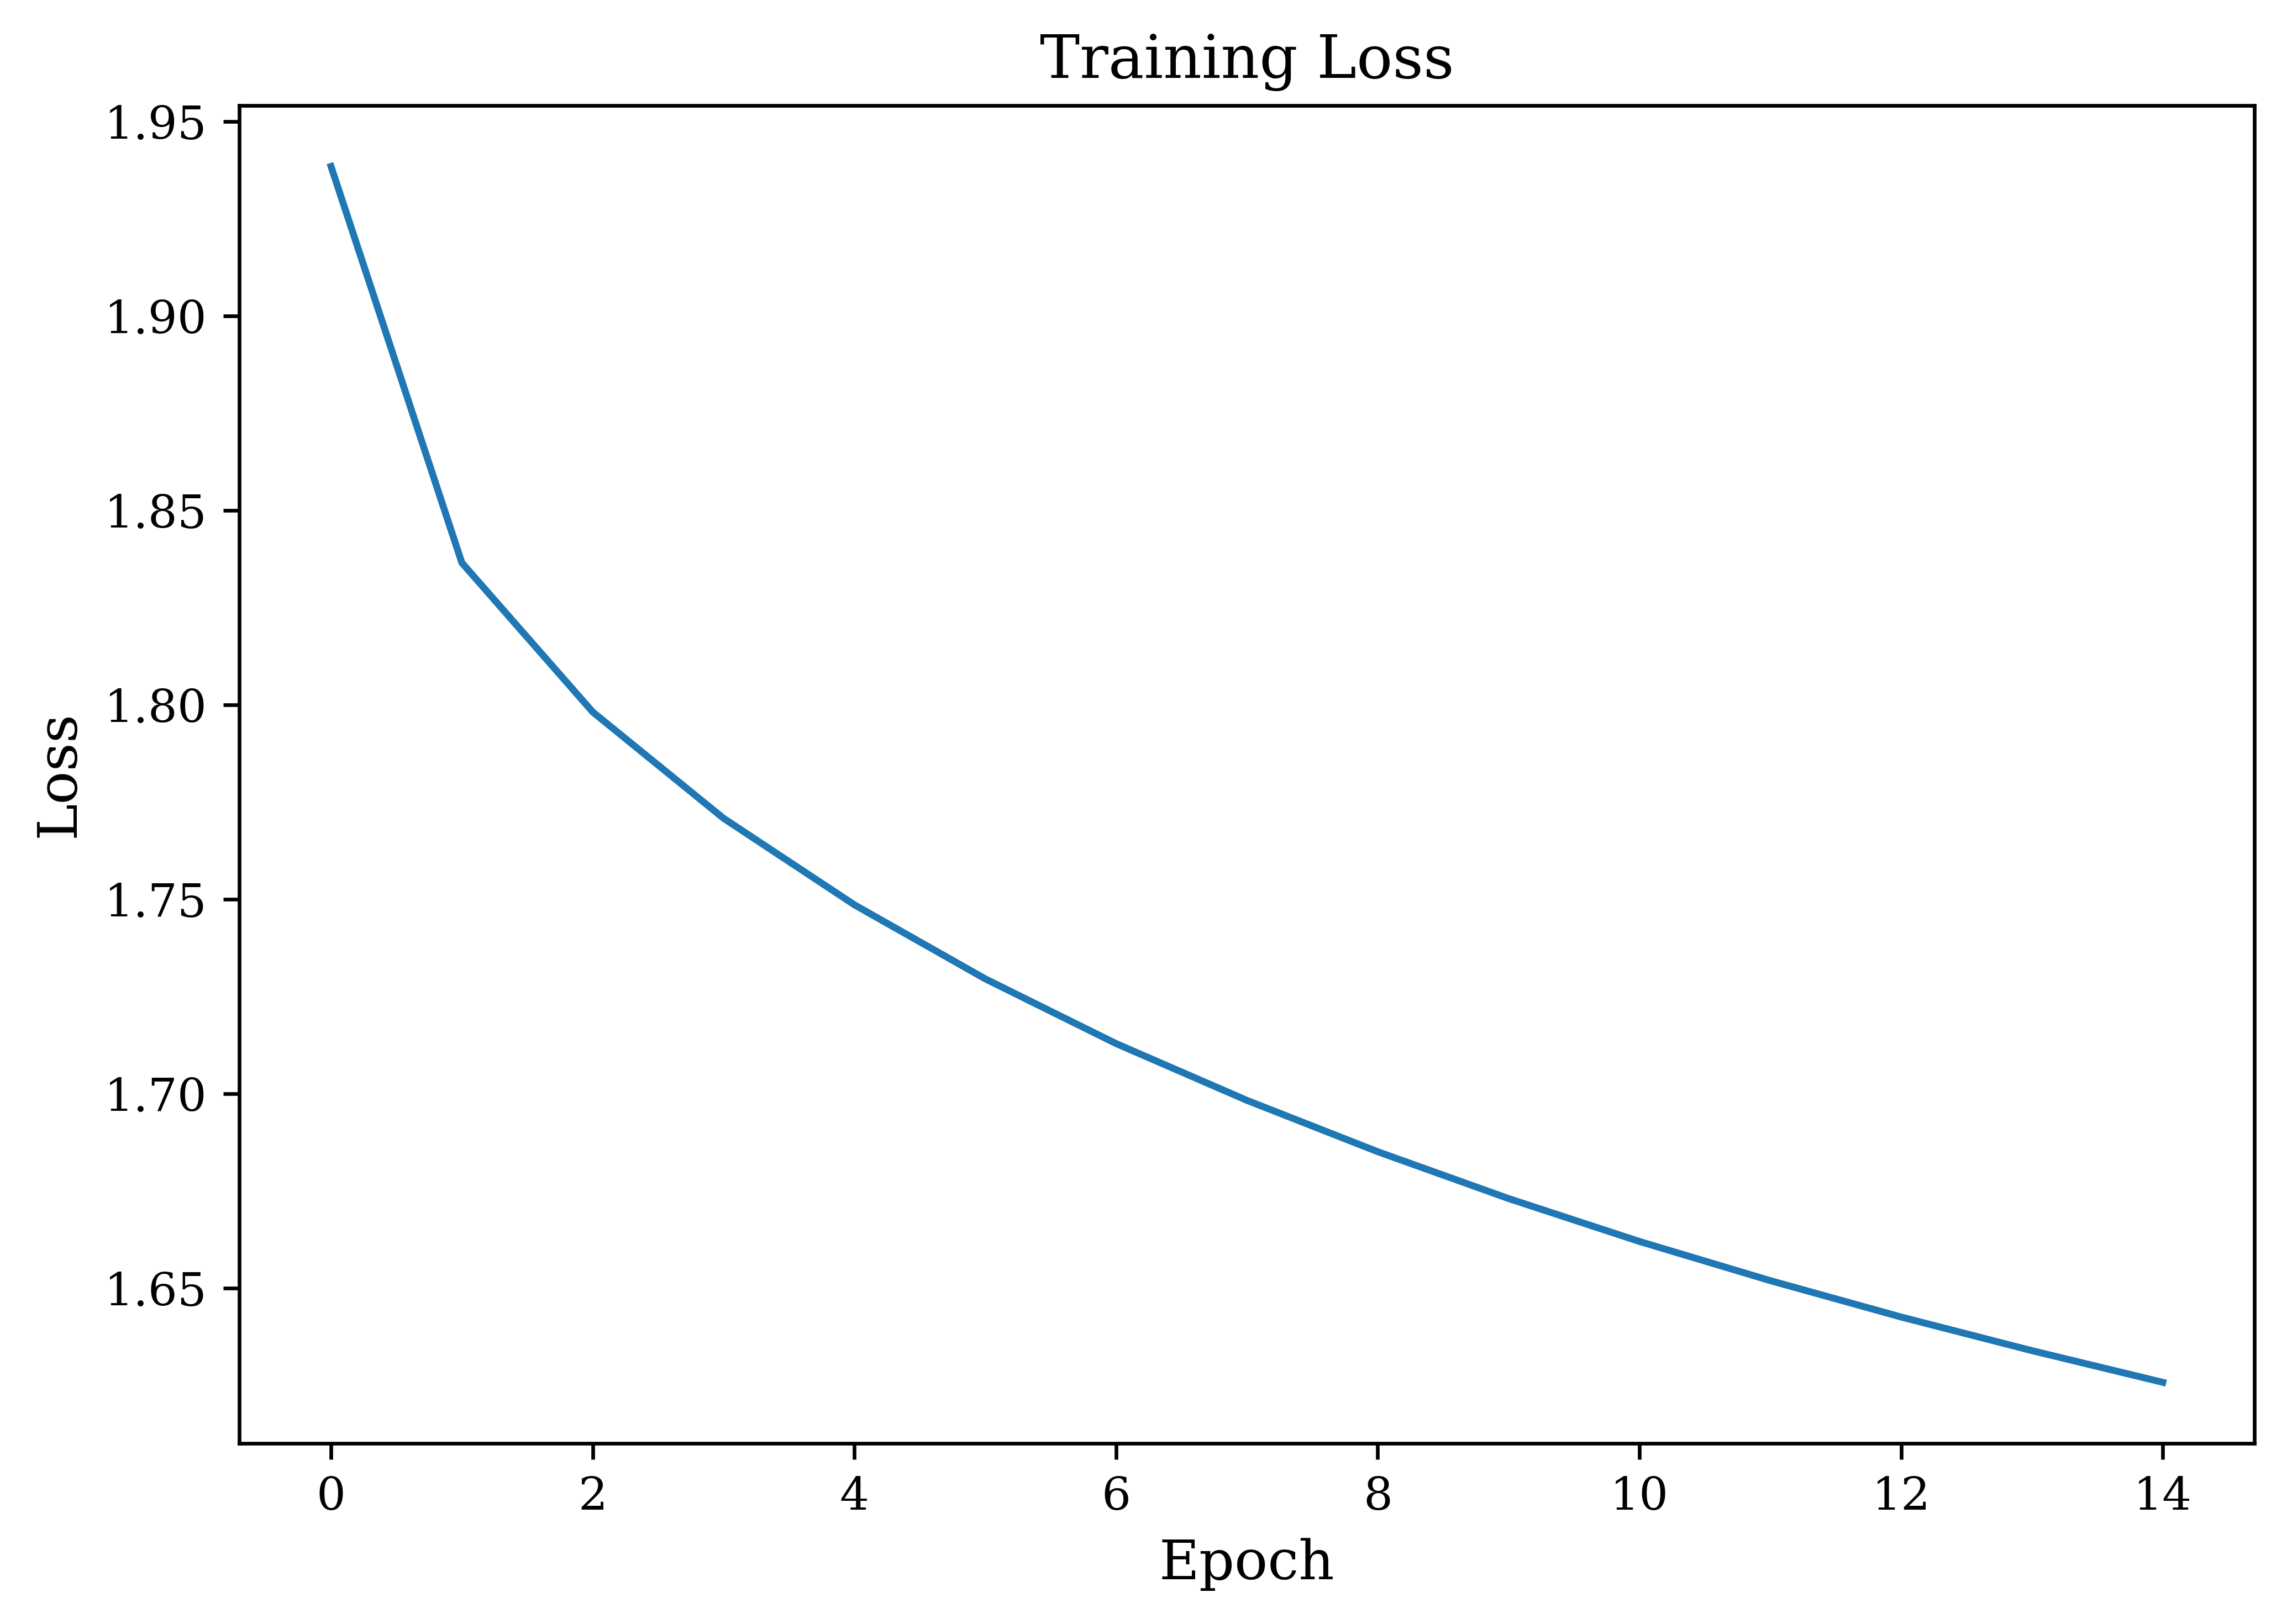

Saved: /content/plots/05_validation_loss.eps


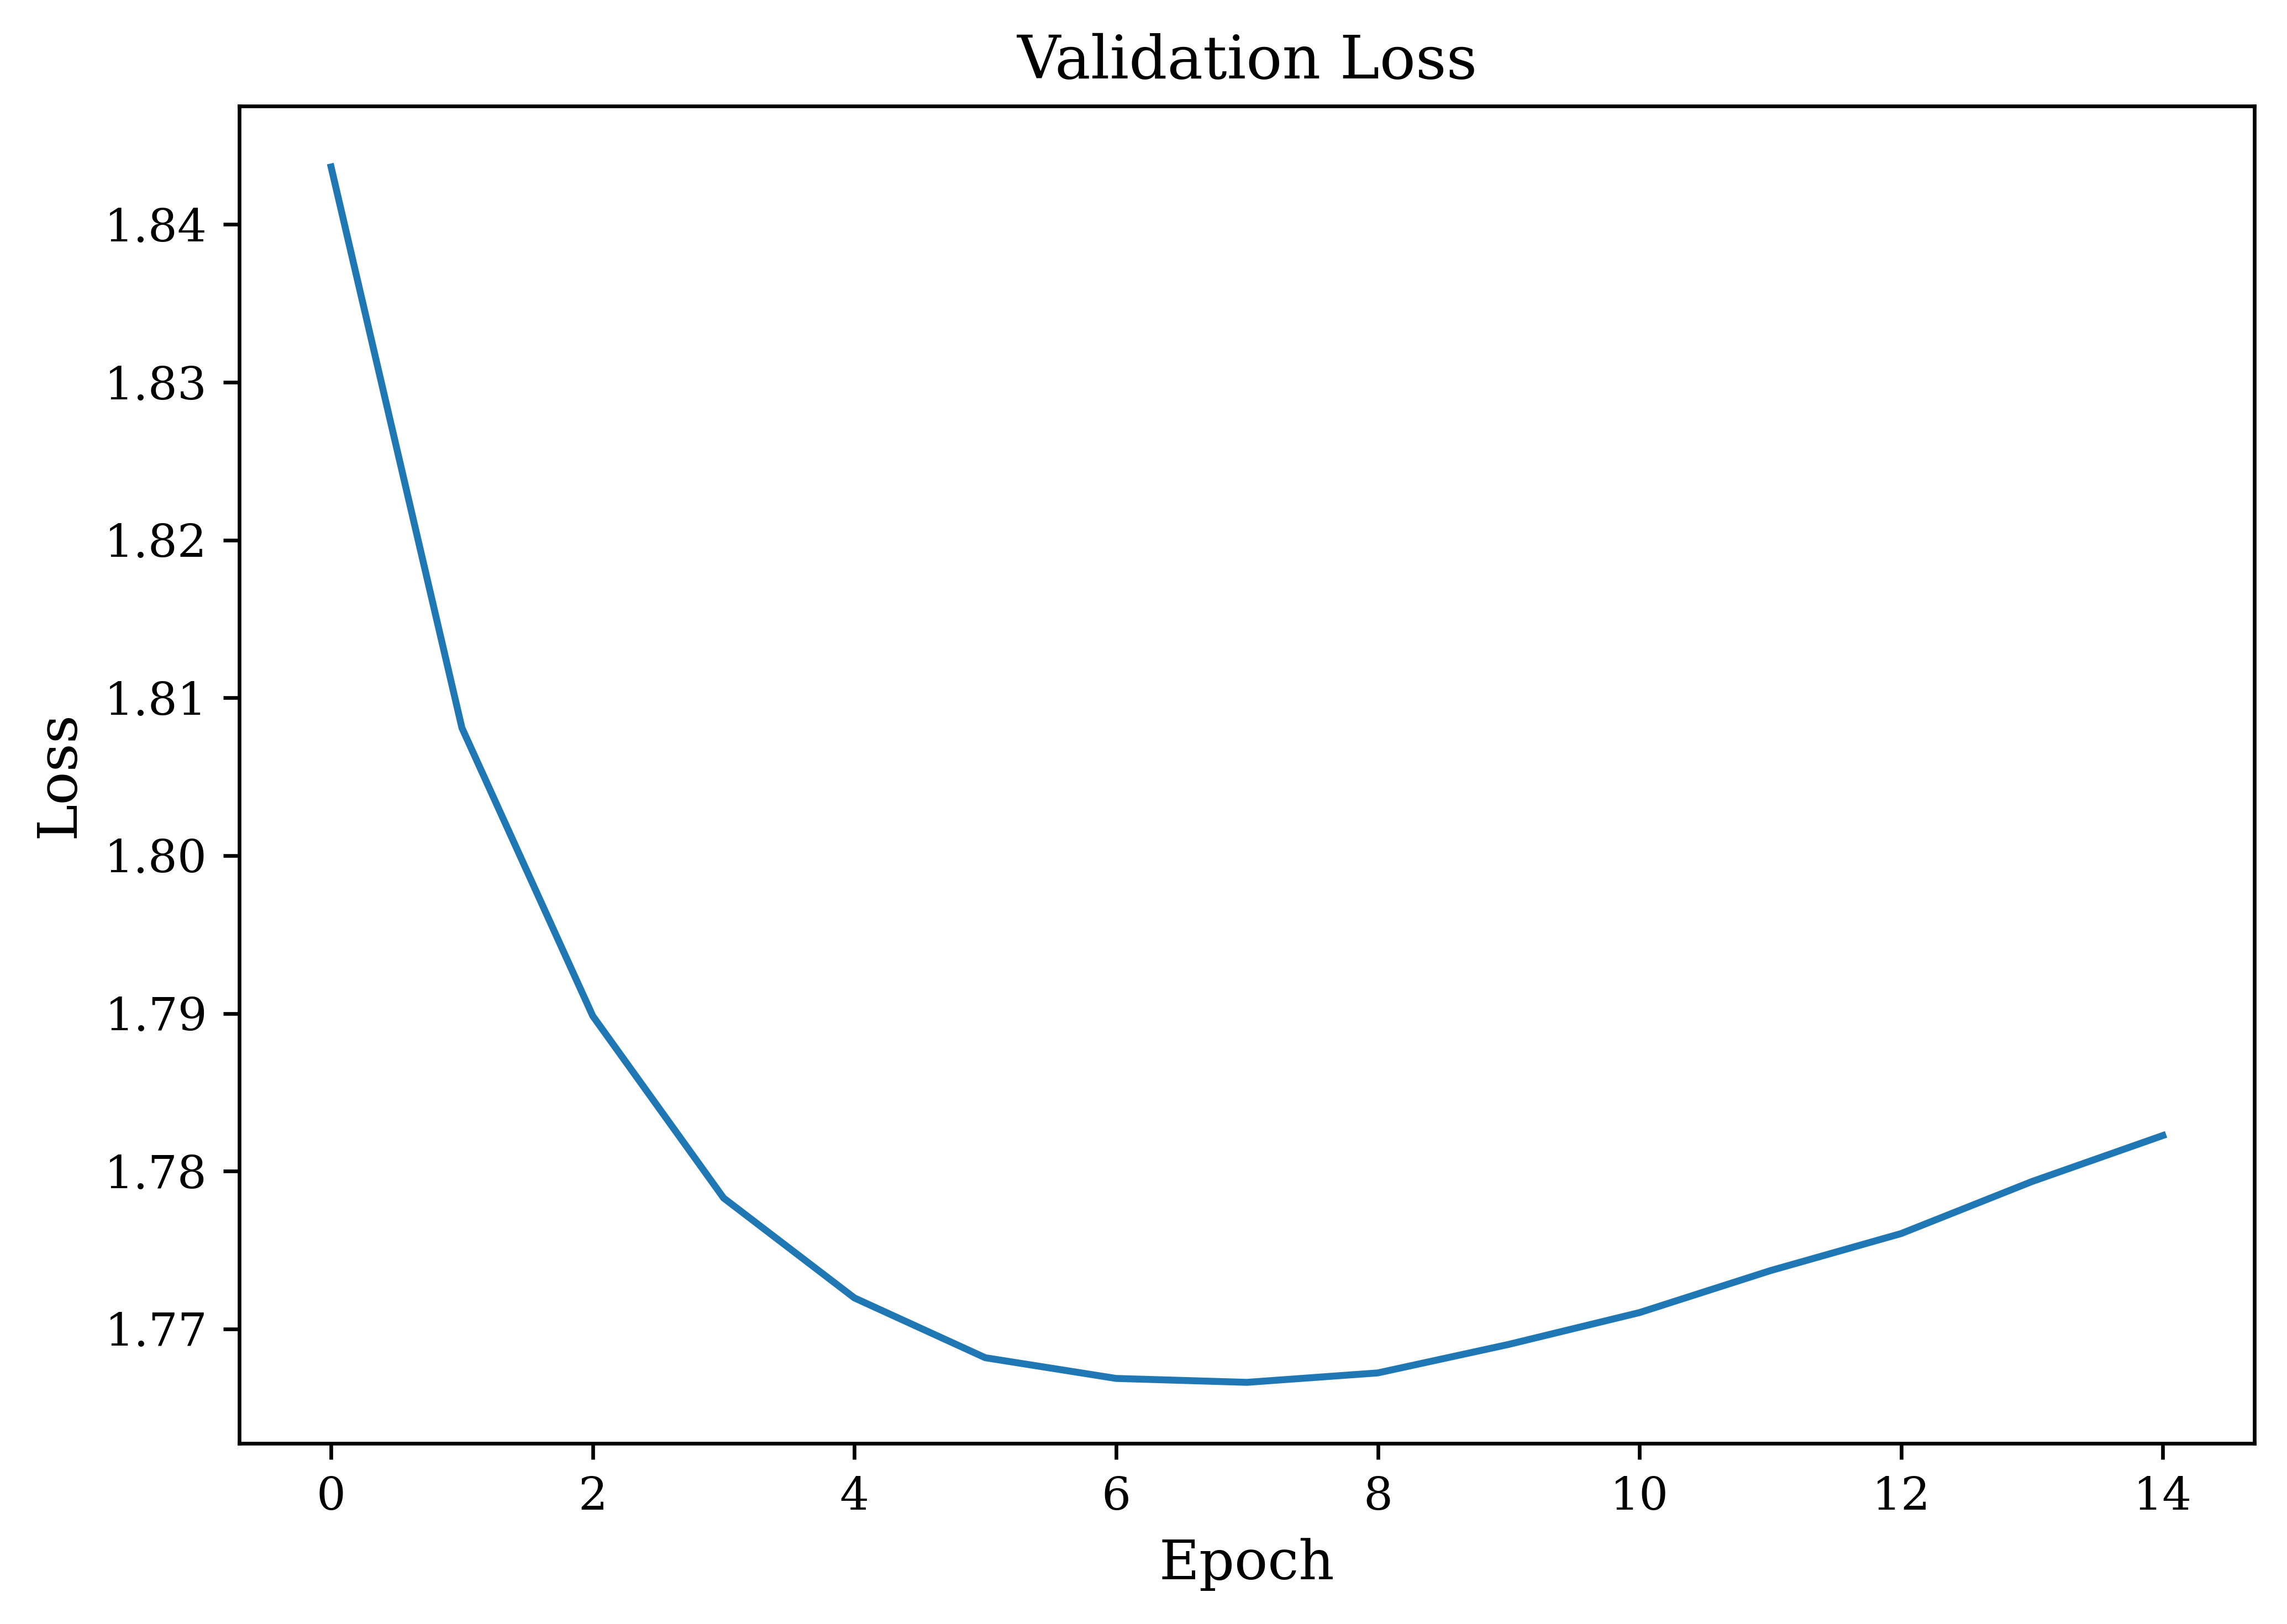

In [ ]:
# ===== CELL 8: Mandatory Plots 2-5 (Training/Validation Accuracy and Loss) =====
def plot_single_metric(history, key, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(history.history[key])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    fig.tight_layout()
    save_plot(fig, filename)
    plt.show()

plot_single_metric(history_frozen, "accuracy", "Training Accuracy", "Accuracy", "02_training_accuracy")
plot_single_metric(history_frozen, "val_accuracy", "Validation Accuracy", "Accuracy", "03_validation_accuracy")
plot_single_metric(history_frozen, "loss", "Training Loss", "Loss", "04_training_loss")
plot_single_metric(history_frozen, "val_loss", "Validation Loss", "Loss", "05_validation_loss")


In [ ]:
# ## Task 4: Fine Tuning
#
# 1. Unfreeze the last convolution block.
# 2. Train for another 5-10 epochs.
# 3. Compare the classification accuracy before and after fine tuning.

# ===== CELL 9: Unfreeze the last convolution block =====
print(f"Total layers in MobileNetV2 base: {len(base_model.layers)}")

UNFREEZE_FROM = len(base_model.layers) - 30  # "last convolution block"

base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


Total layers in MobileNetV2 base: 154


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [ ]:
# ===== CELL 10: Train for another 5-10 epochs =====
t0 = time.time()
history_finetune = model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    batch_size=32,
    epochs=8,
)
finetune_train_time = time.time() - t0

test_loss_ft, test_acc_ft = model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Fine-tuned test accuracy: {test_acc_ft:.4f}")


Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.3716 - loss: 2.5181 - val_accuracy: 0.2518 - val_loss: 2.2791
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4923 - loss: 1.4416 - val_accuracy: 0.4758 - val_loss: 1.5290
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5375 - loss: 1.3301 - val_accuracy: 0.4422 - val_loss: 1.9621
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5616 - loss: 1.2654 - val_accuracy: 0.5112 - val_loss: 1.4115
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5801 - loss: 1.2193 - val_accuracy: 0.5430 - val_loss: 1.4887
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.5936 - loss: 1.1920 - val_accuracy: 0.5470 - val_loss: 1.4419
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5896 - loss: 1.1784 - val_accuracy: 0.5642 - val_loss: 1.3047
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6078 - loss: 1.1251 -

Saved: /content/plots/06_finetune_comparison.eps


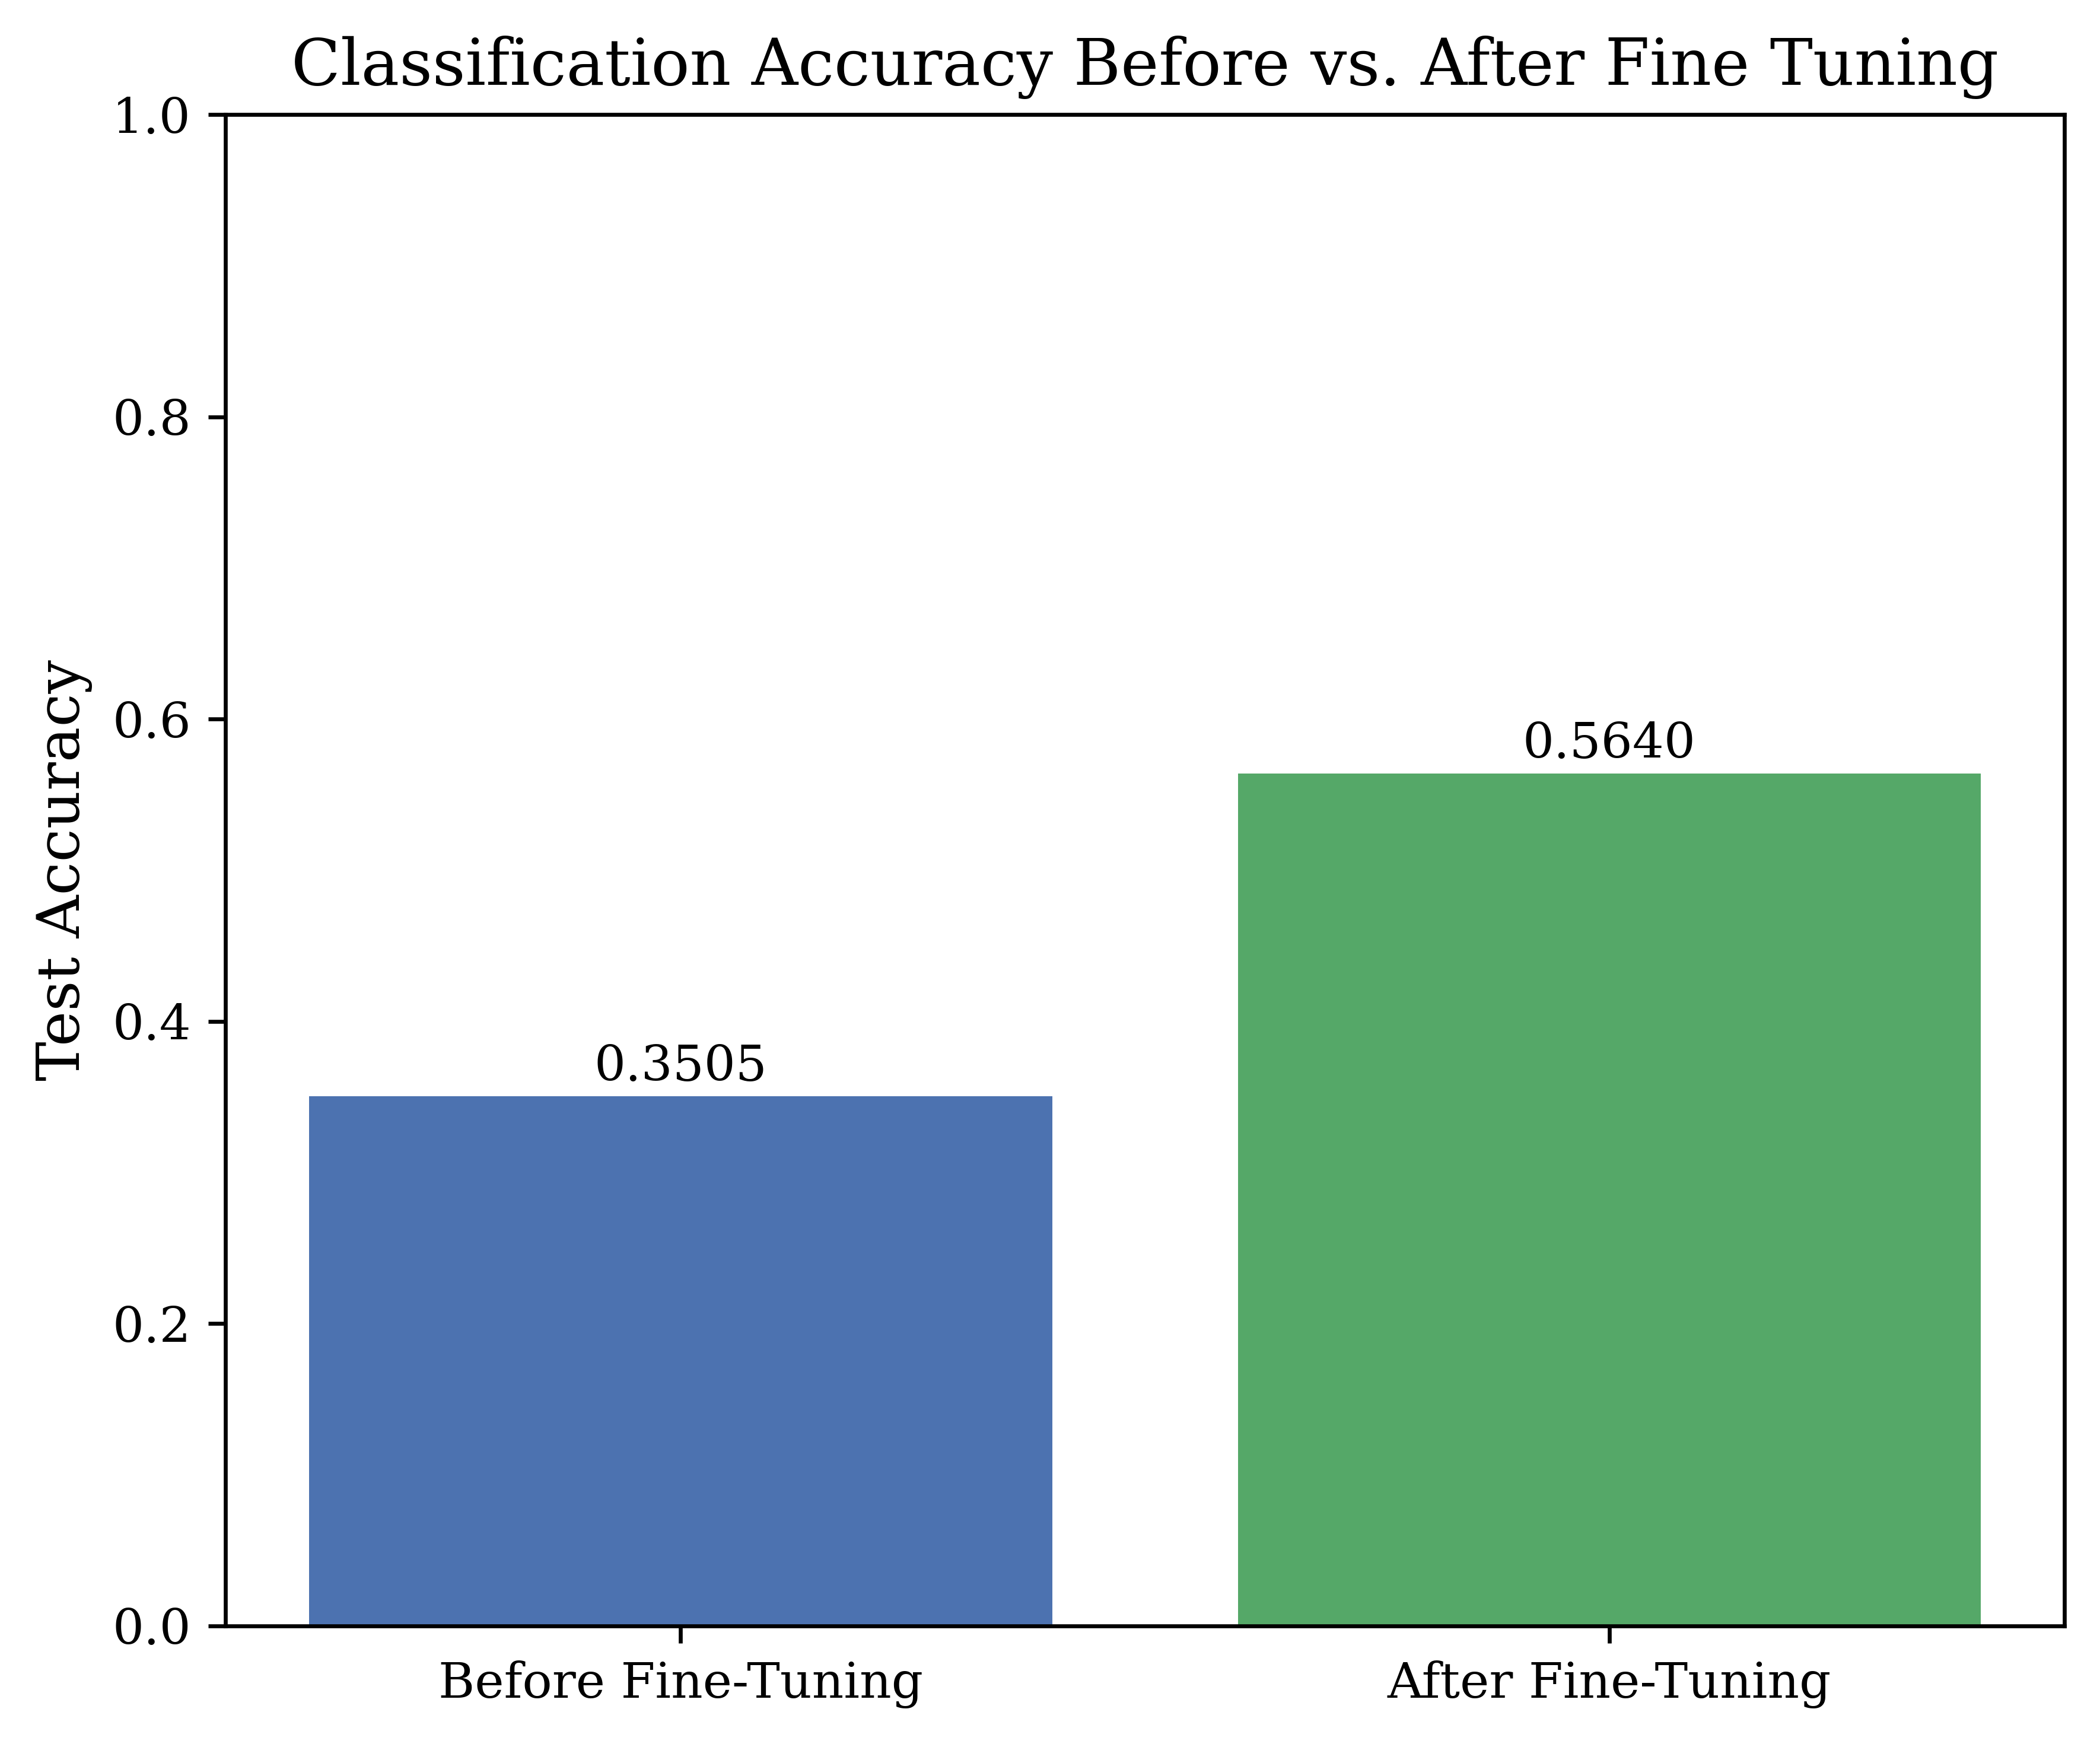

In [ ]:
# ===== CELL 11: Compare accuracy before vs. after fine tuning =====
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Before Fine-Tuning", "After Fine-Tuning"], [test_acc_frozen, test_acc_ft],
              color=["#4C72B0", "#55A868"])
ax.set_ylabel("Test Accuracy")
ax.set_title("Classification Accuracy Before vs. After Fine Tuning")
ax.set_ylim(0, 1)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.4f}", ha="center")
fig.tight_layout()
save_plot(fig, "06_finetune_comparison")
plt.show()


In [ ]:
# ## Task 5: Model Evaluation

# ===== CELL 12: Accuracy, Precision, Recall, F1-score, Classification Report =====
y_pred_probs = model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"Test Accuracy    : {test_acc:.4f}")
print(f"Precision(macro) : {precision:.4f}")
print(f"Recall(macro)    : {recall:.4f}")
print(f"F1-score(macro)  : {f1:.4f}\n")

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

with open(os.path.join(PLOT_DIR, "07_classification_report.txt"), "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Precision(macro): {precision:.4f}\nRecall(macro): {recall:.4f}\nF1(macro): {f1:.4f}\n\n")
    f.write(report)


Test Accuracy    : 0.5640
Precision(macro) : 0.5870
Recall(macro)    : 0.5640
F1-score(macro)  : 0.5601

              precision    recall  f1-score   support

    airplane       0.68      0.62      0.65      1000
  automobile       0.61      0.68      0.64      1000
        bird       0.54      0.41      0.47      1000
         cat       0.54      0.34      0.42      1000
        deer       0.50      0.65      0.56      1000
         dog       0.47      0.65      0.54      1000
        frog       0.46      0.67      0.54      1000
       horse       0.67      0.54      0.60      1000
        ship       0.62      0.68      0.65      1000
       truck       0.80      0.40      0.53      1000

    accuracy                           0.56     10000
   macro avg       0.59      0.56      0.56     10000
weighted avg       0.59      0.56      0.56     10000



Saved: /content/plots/08_confusion_matrix.eps


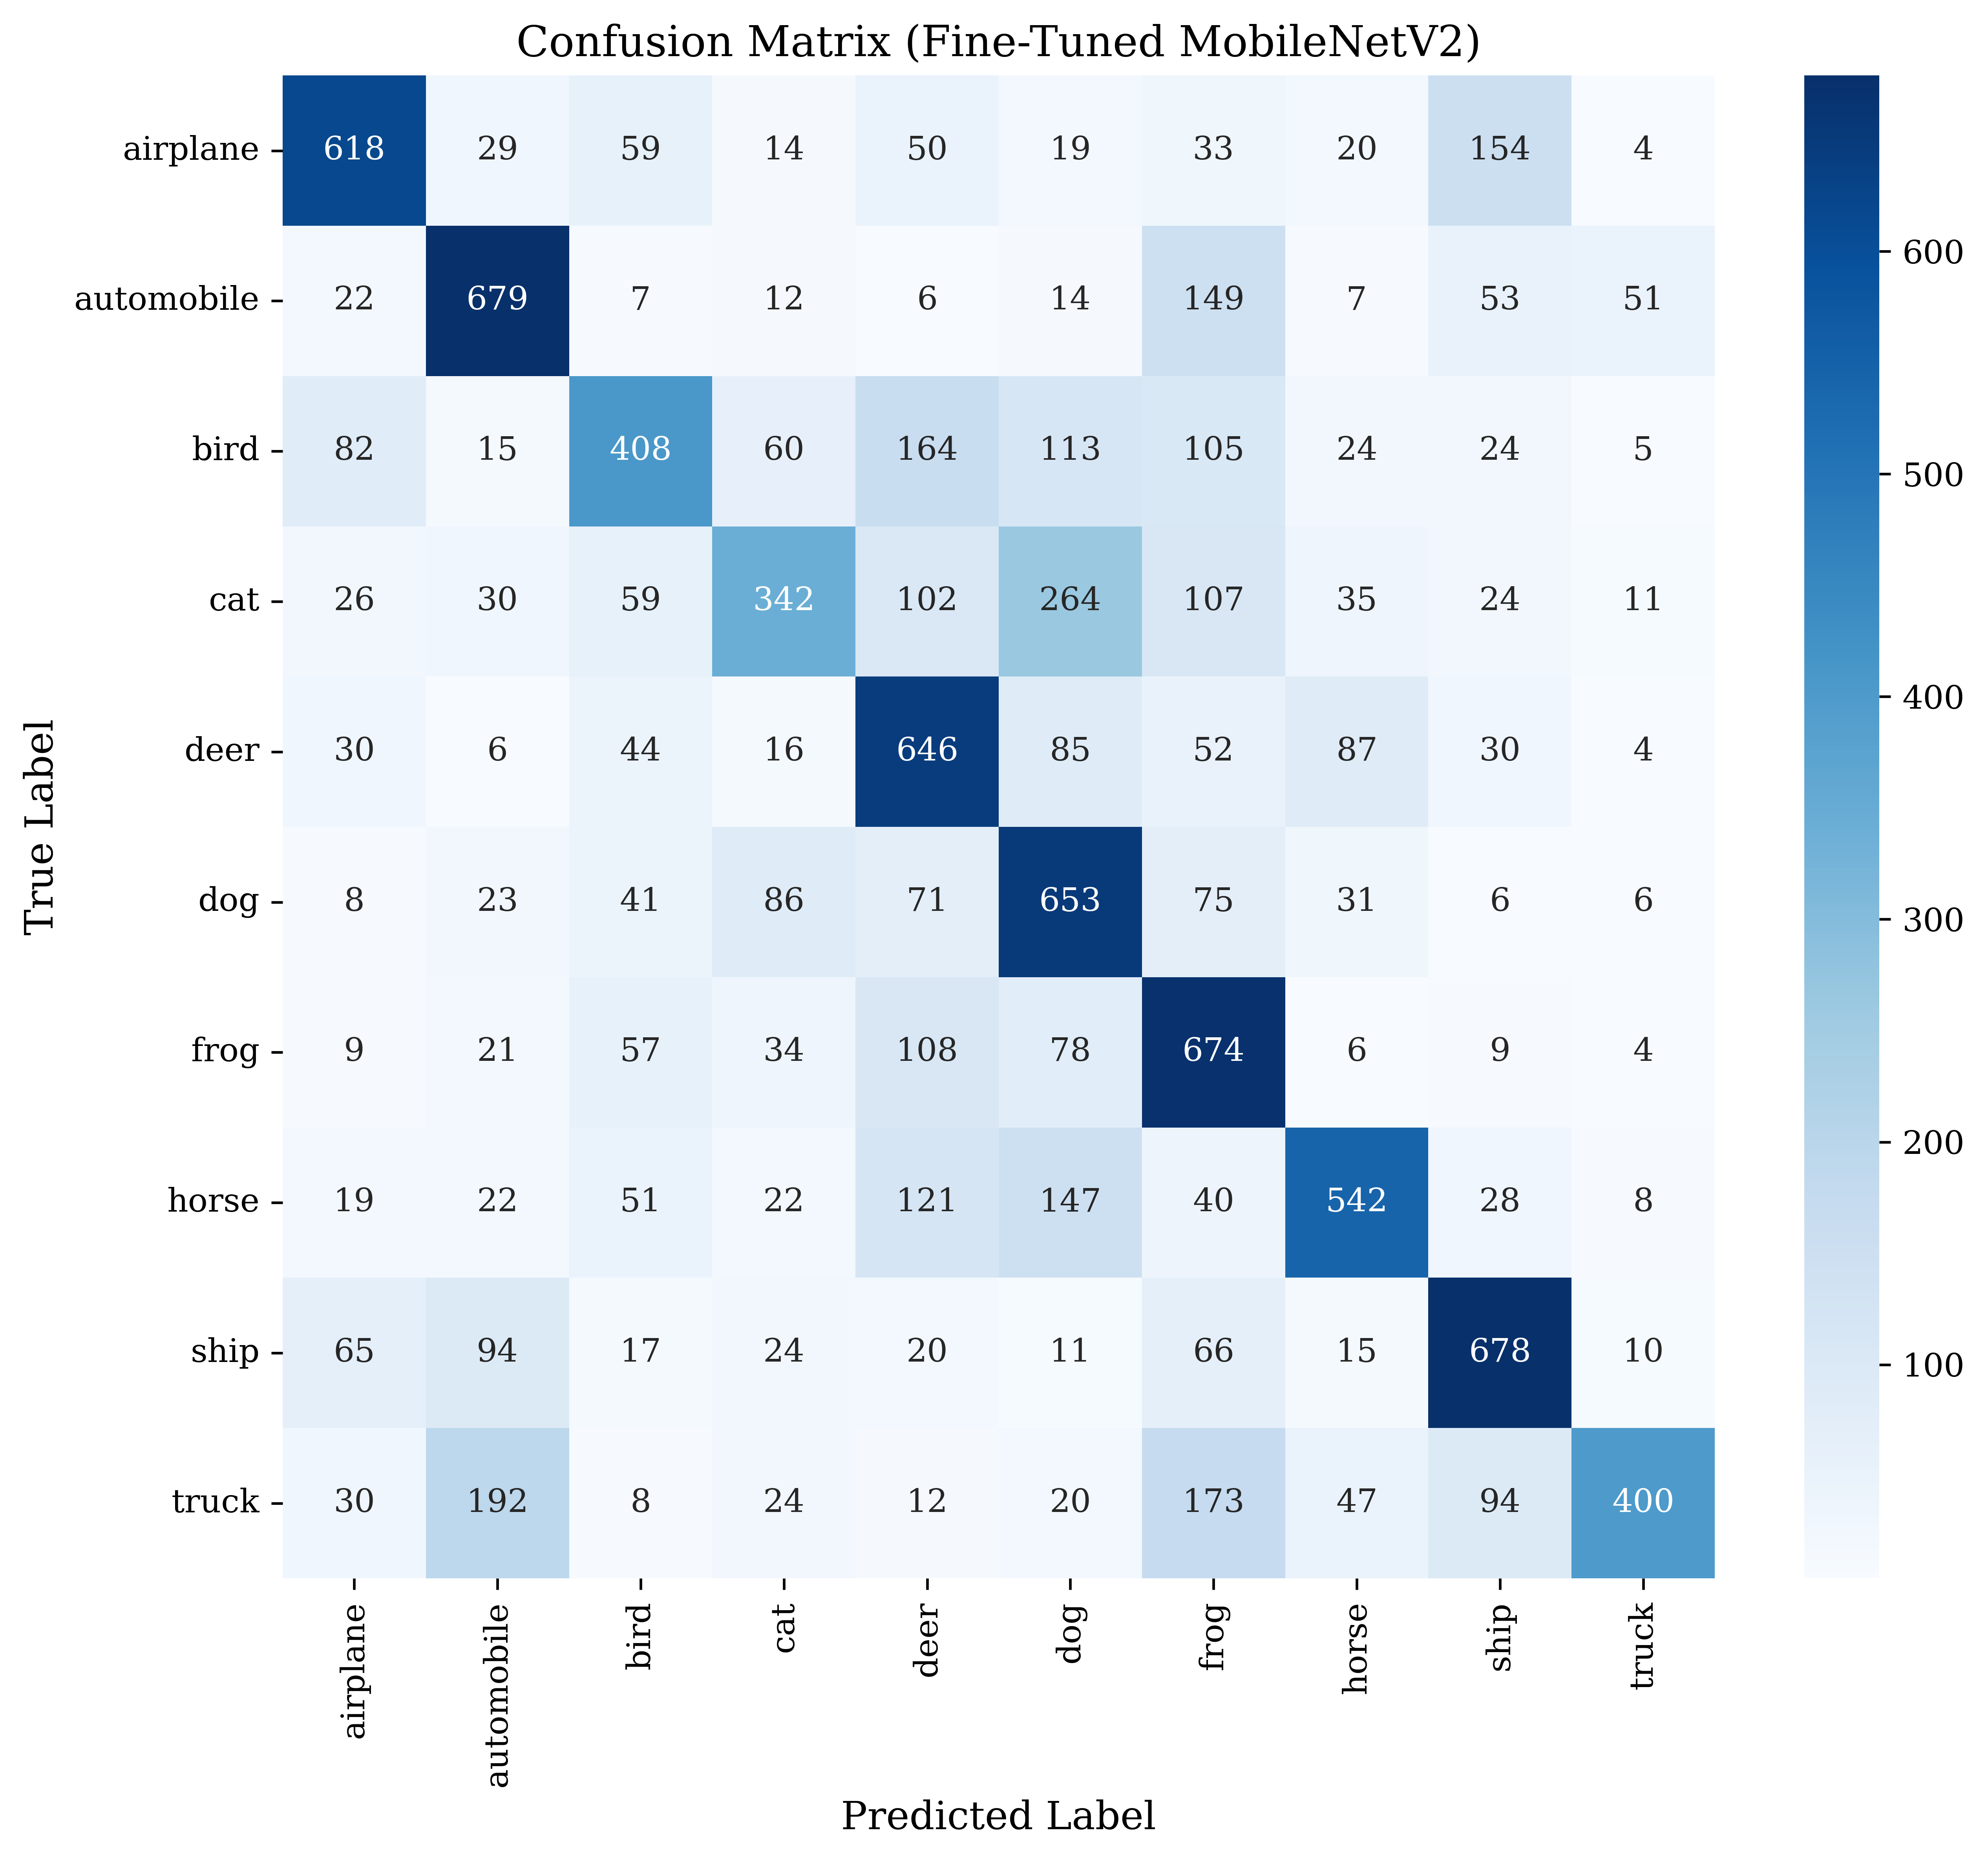

In [ ]:
# ===== CELL 13: Confusion Matrix =====
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix (Fine-Tuned MobileNetV2)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.tight_layout()
save_plot(fig, "08_confusion_matrix")
plt.show()


Saved: /content/plots/09_misclassified_images.eps


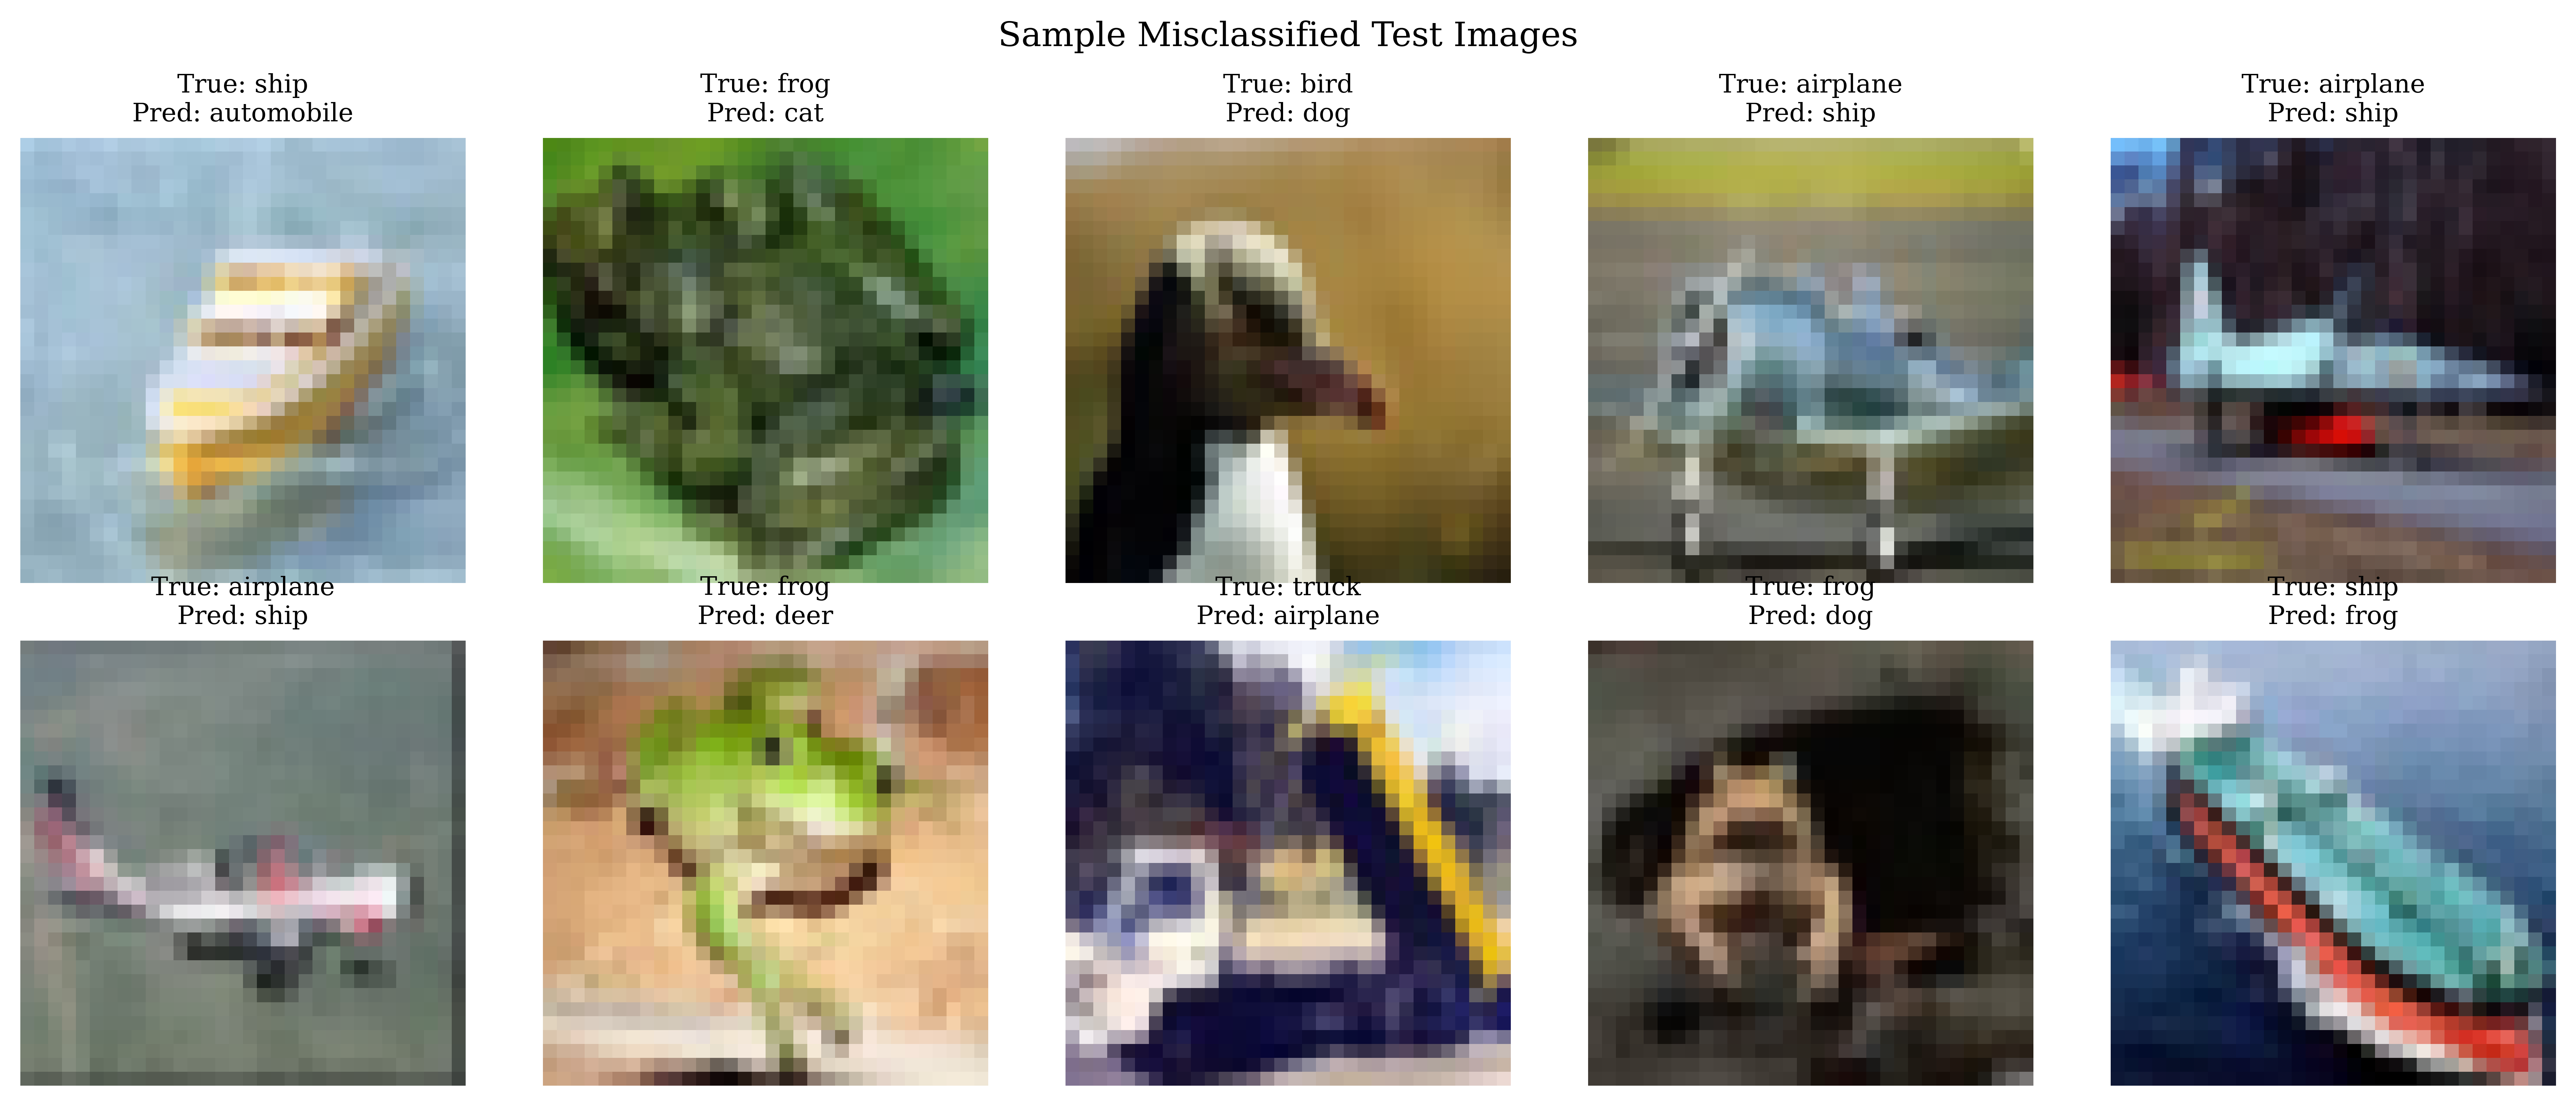

In [ ]:
# ===== CELL 14: Misclassified Images (Optional Mandatory Plot 7) =====
misclassified_idx = np.where(y_pred != y_true)[0]
sample_wrong = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for ax, idx in zip(axes.flat, sample_wrong):
    ax.imshow(x_test_norm[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Sample Misclassified Test Images")
fig.tight_layout()
save_plot(fig, "09_misclassified_images")
plt.show()


In [ ]:
# ## Section 16: Hyperparameter Study
#
# Learning Rate: 0.001, 0.0001 | Batch Size: 16, 32, 64 | Epochs: 10, 20 |
# Optimizer: Adam, SGD | Dense Units: 128, 256 | Frozen Layers: All, Partial
#
# Each hyperparameter is varied one at a time against the Task 3 baseline. LR/batch/optimizer/
# dense-units/frozen-layer comparisons use short 3-epoch runs (a comparative proxy, since the
# manual does not fix an exact epoch count for this sweep); the Epochs hyperparameter itself is
# run at its actual stated values (10 and 20), since that is the variable under test.

# ===== CELL 15: Build function for hyperparameter sweeps =====
def build_mobilenet_model(dense_units=128, optimizer_name="adam", learning_rate=0.001, frozen="all"):
    base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")
    if frozen == "all":
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:len(base.layers) - 30]:
            layer.trainable = False

    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

    opt = (optimizers.Adam(learning_rate=learning_rate) if optimizer_name == "adam"
           else optimizers.SGD(learning_rate=learning_rate, momentum=0.9))
    m.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def quick_train_eval(m, epochs=3, batch_size=32, tag=""):
    h = m.fit(x_train_norm, y_train_cat, validation_split=0.1,
              batch_size=batch_size, epochs=epochs, verbose=0)
    val_acc = h.history["val_accuracy"][-1]
    print(f"[{tag}] final val_accuracy = {val_acc:.4f}")
    return val_acc

hp_results = {}


In [ ]:
# ### Learning Rate: 0.001 vs 0.0001

for lr in [0.001, 0.0001]:
    m = build_mobilenet_model(learning_rate=lr)
    tag = f"lr_{lr}"
    hp_results[tag] = quick_train_eval(m, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[lr_0.001] final val_accuracy = 0.3588
[lr_0.0001] final val_accuracy = 0.3244


In [ ]:
# ### Batch Size: 16 vs 32 vs 64

for bs in [16, 32, 64]:
    m = build_mobilenet_model()
    tag = f"batch_{bs}"
    hp_results[tag] = quick_train_eval(m, batch_size=bs, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[batch_16] final val_accuracy = 0.3536
[batch_32] final val_accuracy = 0.3542
[batch_64] final val_accuracy = 0.3542


In [ ]:
# ### Epochs: 10 vs 20 (run at their actual stated values)

for ep in [10, 20]:
    m = build_mobilenet_model()
    tag = f"epochs_{ep}"
    hp_results[tag] = quick_train_eval(m, epochs=ep, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[epochs_10] final val_accuracy = 0.3674
[epochs_20] final val_accuracy = 0.3592


In [ ]:
# ### Optimizer: Adam vs SGD

for opt in ["adam", "sgd"]:
    m = build_mobilenet_model(optimizer_name=opt)
    tag = f"optimizer_{opt}"
    hp_results[tag] = quick_train_eval(m, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[optimizer_adam] final val_accuracy = 0.3530
[optimizer_sgd] final val_accuracy = 0.2986


In [ ]:
# ### Dense Units: 128 vs 256

for du in [128, 256]:
    m = build_mobilenet_model(dense_units=du)
    tag = f"dense_{du}"
    hp_results[tag] = quick_train_eval(m, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[dense_128] final val_accuracy = 0.3562
[dense_256] final val_accuracy = 0.3624


In [ ]:
# ### Frozen Layers: All vs Partial

for frz in ["all", "partial"]:
    m = build_mobilenet_model(frozen=frz)
    tag = f"frozen_{frz}"
    hp_results[tag] = quick_train_eval(m, tag=tag)


/tmp/ipykernel_1005/1249948732.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights="imagenet")


[frozen_all] final val_accuracy = 0.3544
[frozen_partial] final val_accuracy = 0.5590


/tmp/ipykernel_1005/749327952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(hp_results.keys()), y=list(hp_results.values()), palette="mako", ax=ax)


Saved: /content/plots/10_hyperparameter_study.eps


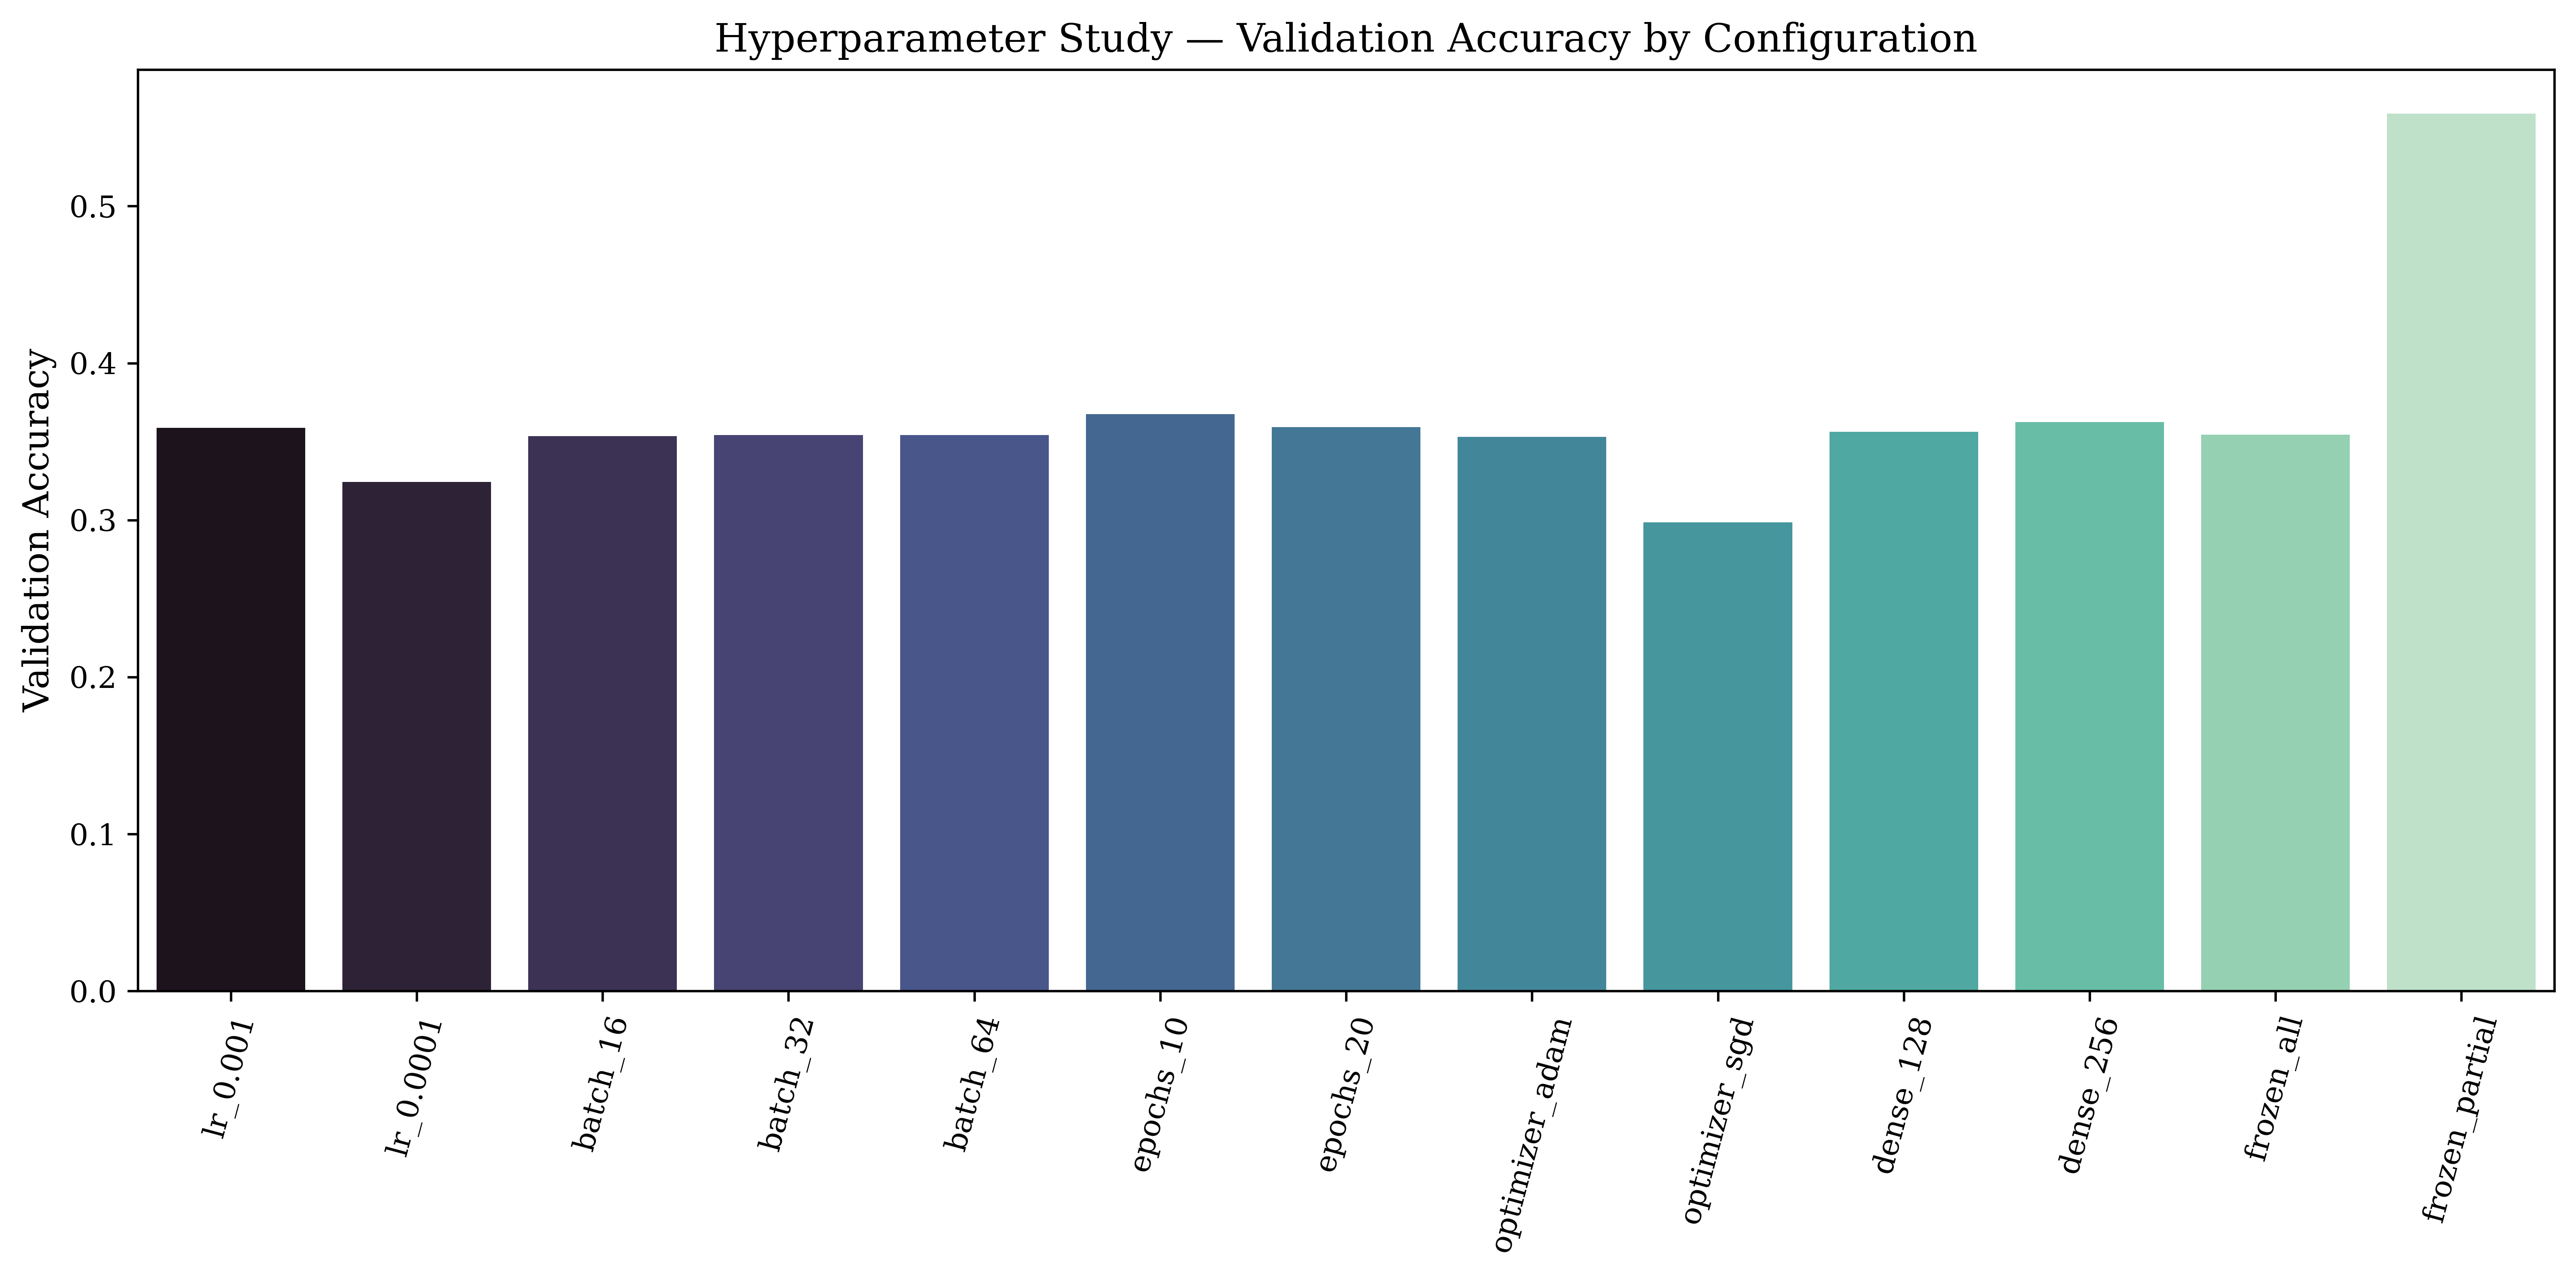

lr_0.001: 0.3588
lr_0.0001: 0.3244
batch_16: 0.3536
batch_32: 0.3542
batch_64: 0.3542
epochs_10: 0.3674
epochs_20: 0.3592
optimizer_adam: 0.3530
optimizer_sgd: 0.2986
dense_128: 0.3562
dense_256: 0.3624
frozen_all: 0.3544
frozen_partial: 0.5590


In [ ]:
# ===== CELL 16: Hyperparameter comparison chart =====
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=list(hp_results.keys()), y=list(hp_results.values()), palette="mako", ax=ax)
ax.tick_params(axis='x', rotation=75)
ax.set_ylabel("Validation Accuracy")
ax.set_title("Hyperparameter Study — Validation Accuracy by Configuration")
fig.tight_layout()
save_plot(fig, "10_hyperparameter_study")
plt.show()

with open(os.path.join(PLOT_DIR, "11_hyperparameter_results.txt"), "w") as f:
    for k, v in hp_results.items():
        f.write(f"{k}: {v:.4f}\n")
        print(f"{k}: {v:.4f}")


In [ ]:
# ## Section 18: Results
#
# ### 18.1 Performance Metrics

# ===== CELL 17: Fill Table 18.1 with measured values =====
metrics_text = (
    f"{'Metric':25s}{'Value'}\n"
    f"{'Training Accuracy':25s}{history_frozen.history['accuracy'][-1]:.4f}\n"
    f"{'Testing Accuracy':25s}{test_acc:.4f}\n"
    f"{'Precision':25s}{precision:.4f}\n"
    f"{'Recall':25s}{recall:.4f}\n"
    f"{'F1-score':25s}{f1:.4f}\n"
    f"{'Training Time (s)':25s}{frozen_train_time + finetune_train_time:.1f}\n"
    f"{'Total Parameters':25s}{total_params:,}\n"
)
print(metrics_text)
with open(os.path.join(PLOT_DIR, "12_performance_metrics.txt"), "w") as f:
    f.write(metrics_text)


Metric                   Value
Training Accuracy        0.4116
Testing Accuracy         0.5640
Precision                0.5870
Recall                   0.5640
F1-score                 0.5601
Training Time (s)        302.8
Total Parameters         2,423,242



In [ ]:
# ## Section 19: Discussion Questions
#
# Answer these in your own words for your report:
# 1. Why is AlexNet considered a breakthrough in deep learning?
# 2. Why does VGG16 use only $3\times3$ convolution filters?
# 3. Explain the advantages of the Inception module.
# 4. What is the purpose of residual learning?
# 5. Differentiate LeNet and ResNet.
# 6. What is Transfer Learning?
# 7. Why is fine tuning required?
# 8. Explain the difference between dilated convolution and transpose convolution.
# 9. Why do pretrained models converge faster?
# 10. Compare the computational complexity of LeNet and ResNet.
#
# ## Section 20: Additional Exercises
#
# 1. Implement transfer learning using VGG16.
# 2. Repeat the experiment using ResNet50.
# 3. Compare Adam and SGD optimizers. *(done in Section 16)*
# 4. Compare training with frozen layers and fine tuning. *(done in Tasks 3-4)*
# 5. Evaluate the model using Precision, Recall and F1-score. *(done in Task 5)*
# 6. Compare the performance of LeNet, AlexNet and ResNet.
#
# For items 1, 2 and 6, an 8,000-image stratified subset (800 per class) of the training set is
# used to keep training time reasonable, as requested; the full 10,000-image test set is still used
# for evaluation.

# ===== CELL 19: Build the 8,000-image stratified training subset =====
def stratified_subset(x, y, per_class=800, seed=SEED):
    rng = np.random.RandomState(seed)
    idx_list = []
    y_flat = y.flatten()
    for c in range(10):
        class_idx = np.where(y_flat == c)[0]
        chosen = rng.choice(class_idx, size=per_class, replace=False)
        idx_list.append(chosen)
    idx = np.concatenate(idx_list)
    rng.shuffle(idx)
    return x[idx], y[idx]

x_sub, y_sub = stratified_subset(x_train, y_train, per_class=800)
x_sub_norm = x_sub.astype("float32") / 255.0
y_sub_cat = to_categorical(y_sub, 10)

print(f"Subset size: {x_sub.shape[0]} images ({x_sub.shape[0] // 10} per class)")


Subset size: 8000 images (800 per class)


In [ ]:
# ===== CELL 20: VGG16 transfer learning (Additional Exercise 1) =====
vgg16_base = VGG16(input_shape=(32, 32, 3), include_top=False, weights="imagenet")
vgg16_base.trainable = False

vgg16_model = models.Sequential([
    vgg16_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
vgg16_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                     loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
vgg16_model.fit(x_sub_norm, y_sub_cat, validation_split=0.1, batch_size=32, epochs=10, verbose=2)
vgg16_train_time = time.time() - t0

_, vgg16_test_acc = vgg16_model.evaluate(x_test_norm, y_test_cat, verbose=0)
vgg16_params = vgg16_model.count_params()
print(f"VGG16 -> test accuracy: {vgg16_test_acc:.4f}, params: {vgg16_params:,}, time: {vgg16_train_time:.1f}s")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
225/225 - 6s - 28ms/step - accuracy: 0.4149 - loss: 1.6864 - val_accuracy: 0.4563 - val_loss: 1.5598
Epoch 2/10
225/225 - 2s - 9ms/step - accuracy: 0.5244 - loss: 1.3635 - val_accuracy: 0.5025 - val_loss: 1.4625
Epoch 3/10
225/225 - 2s - 9ms/step - accuracy: 0.5607 - loss: 1.2629 - val_accuracy: 0.5088 - val_loss: 1.4174
Epoch 4/10
225/225 - 2s - 9ms/step - accuracy: 0.5790 - loss: 1.1972 - val_accuracy: 0.5113 - val_loss: 1.3912
Epoch 5/10
225/225 - 2s - 9ms/step - accuracy: 0.5996 - loss: 1.1464 - val_accuracy: 0.5200 - val_loss: 1.3786
Epoch 6/10
225/225 - 2s - 9ms/step - accuracy: 0.6121 - loss: 1.1047 - val_accuracy: 0.5188 - val_loss: 1.3735
Epoch 7/10
225/225 - 2s - 10ms/step - accuracy: 0.6253 - loss: 1.0686 - val_accuracy: 0.5225 - val_loss: 1.3724
Epoch 8/10
225/225 - 2s - 9ms/step - accuracy: 0.6383 - loss: 1.0352 - val_accuracy: 0.5163 - val_loss: 1.3729
Epoch 9/10
225/225 - 2s - 9ms/step - accuracy: 0.6499 - los

In [ ]:
# ===== CELL 21: ResNet50 transfer learning (Additional Exercise 2) =====
resnet50_base = ResNet50(input_shape=(32, 32, 3), include_top=False, weights="imagenet")
resnet50_base.trainable = False

resnet50_model = models.Sequential([
    resnet50_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
resnet50_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                        loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
resnet50_model.fit(x_sub_norm, y_sub_cat, validation_split=0.1, batch_size=32, epochs=10, verbose=2)
resnet50_train_time = time.time() - t0

_, resnet50_test_acc = resnet50_model.evaluate(x_test_norm, y_test_cat, verbose=0)
resnet50_params = resnet50_model.count_params()
print(f"ResNet50 -> test accuracy: {resnet50_test_acc:.4f}, params: {resnet50_params:,}, time: {resnet50_train_time:.1f}s")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
225/225 - 16s - 71ms/step - accuracy: 0.1754 - loss: 2.2959 - val_accuracy: 0.1875 - val_loss: 2.1921
Epoch 2/10
225/225 - 2s - 9ms/step - accuracy: 0.2371 - loss: 2.1015 - val_accuracy: 0.2262 - val_loss: 2.0962
Epoch 3/10
225/225 - 2s - 8ms/step - accuracy: 0.2590 - loss: 2.0341 - val_accuracy: 0.2463 - val_loss: 2.0383
Epoch 4/10
225/225 - 2s - 10ms/step - accuracy: 0.2719 - loss: 1.9903 - val_accuracy: 0.2700 - val_loss: 2.0154
Epoch 5/10
225/225 - 2s - 10ms/step - accuracy: 0.2817 - loss: 1.9603 - val_accuracy: 0.2825 - val_loss: 1.9866
Epoch 6/10
225/225 - 2s - 9ms/step - accuracy: 0.2962 - loss: 1.9340 - val_accuracy: 0.3000 - val_loss: 1.9649
Epoch 7/10
225/225 - 2s - 8ms/step - accuracy: 0.2990 - loss: 1.9159 - val_accuracy: 0.2887 - val_loss: 1.9494
Epoch 8/10
225/225 - 2s - 8ms/step - accuracy: 0.3046 - loss: 1.9006 - val_accuracy: 0.3225 - val_loss: 1.9208
Epoch 9/10
225/225 - 2s - 8ms/step - accuracy: 0.3147 - l

In [ ]:
# ===== CELL 22: LeNet-5 from scratch (Additional Exercise 6, part 1) =====
# No ImageNet weights exist for LeNet-5, so it is trained from scratch on the same subset.
def build_lenet5():
    m = models.Sequential(name="LeNet5")
    m.add(layers.Input(shape=(32, 32, 3)))
    m.add(layers.Conv2D(6, (5, 5), activation="relu", padding="same"))
    m.add(layers.AveragePooling2D((2, 2)))
    m.add(layers.Conv2D(16, (5, 5), activation="relu"))
    m.add(layers.AveragePooling2D((2, 2)))
    m.add(layers.Flatten())
    m.add(layers.Dense(120, activation="relu"))
    m.add(layers.Dense(84, activation="relu"))
    m.add(layers.Dense(10, activation="softmax"))
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

lenet5_model = build_lenet5()
t0 = time.time()
lenet5_model.fit(x_sub_norm, y_sub_cat, validation_split=0.1, batch_size=32, epochs=15, verbose=2)
lenet5_train_time = time.time() - t0

_, lenet5_test_acc = lenet5_model.evaluate(x_test_norm, y_test_cat, verbose=0)
lenet5_params = lenet5_model.count_params()
print(f"LeNet-5 -> test accuracy: {lenet5_test_acc:.4f}, params: {lenet5_params:,}, time: {lenet5_train_time:.1f}s")


Epoch 1/15
225/225 - 5s - 24ms/step - accuracy: 0.2460 - loss: 2.0265 - val_accuracy: 0.3425 - val_loss: 1.8247
Epoch 2/15
225/225 - 2s - 7ms/step - accuracy: 0.3794 - loss: 1.7067 - val_accuracy: 0.3938 - val_loss: 1.6830
Epoch 3/15
225/225 - 1s - 4ms/step - accuracy: 0.4421 - loss: 1.5427 - val_accuracy: 0.4075 - val_loss: 1.6069
Epoch 4/15
225/225 - 1s - 4ms/step - accuracy: 0.4750 - loss: 1.4453 - val_accuracy: 0.4225 - val_loss: 1.5797
Epoch 5/15
225/225 - 1s - 3ms/step - accuracy: 0.5086 - loss: 1.3679 - val_accuracy: 0.4512 - val_loss: 1.5513
Epoch 6/15
225/225 - 1s - 3ms/step - accuracy: 0.5329 - loss: 1.2934 - val_accuracy: 0.4437 - val_loss: 1.5717
Epoch 7/15
225/225 - 1s - 4ms/step - accuracy: 0.5585 - loss: 1.2228 - val_accuracy: 0.4363 - val_loss: 1.6060
Epoch 8/15
225/225 - 1s - 3ms/step - accuracy: 0.5843 - loss: 1.1611 - val_accuracy: 0.4350 - val_loss: 1.6538
Epoch 9/15
225/225 - 1s - 3ms/step - accuracy: 0.6033 - loss: 1.1047 - val_accuracy: 0.4387 - val_loss: 1.6881


In [ ]:
# ===== CELL 23: AlexNet-style CNN from scratch (Additional Exercise 6, part 2) =====
# Depth/width-matched adaptation of AlexNet for 32x32 input (the original expects 227x227).
def build_alexnet_style():
    m = models.Sequential(name="AlexNet_style")
    m.add(layers.Input(shape=(32, 32, 3)))
    m.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Conv2D(192, (3, 3), activation="relu", padding="same"))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Conv2D(384, (3, 3), activation="relu", padding="same"))
    m.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
    m.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Flatten())
    m.add(layers.Dense(1024, activation="relu"))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(1024, activation="relu"))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(10, activation="softmax"))
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m

alexnet_model = build_alexnet_style()
t0 = time.time()
alexnet_model.fit(x_sub_norm, y_sub_cat, validation_split=0.1, batch_size=32, epochs=15, verbose=2)
alexnet_train_time = time.time() - t0

_, alexnet_test_acc = alexnet_model.evaluate(x_test_norm, y_test_cat, verbose=0)
alexnet_params = alexnet_model.count_params()
print(f"AlexNet-style -> test accuracy: {alexnet_test_acc:.4f}, params: {alexnet_params:,}, time: {alexnet_train_time:.1f}s")


Epoch 1/15
225/225 - 10s - 44ms/step - accuracy: 0.0922 - loss: 2.3050 - val_accuracy: 0.1187 - val_loss: 2.3024
Epoch 2/15
225/225 - 3s - 12ms/step - accuracy: 0.0903 - loss: 2.3038 - val_accuracy: 0.0862 - val_loss: 2.3029
Epoch 3/15
225/225 - 3s - 12ms/step - accuracy: 0.1010 - loss: 2.3033 - val_accuracy: 0.0862 - val_loss: 2.3033
Epoch 4/15
225/225 - 3s - 12ms/step - accuracy: 0.0961 - loss: 2.3032 - val_accuracy: 0.0812 - val_loss: 2.3034
Epoch 5/15
225/225 - 3s - 13ms/step - accuracy: 0.0953 - loss: 2.3032 - val_accuracy: 0.0862 - val_loss: 2.3036
Epoch 6/15
225/225 - 3s - 12ms/step - accuracy: 0.0997 - loss: 2.3032 - val_accuracy: 0.0812 - val_loss: 2.3036
Epoch 7/15
225/225 - 3s - 12ms/step - accuracy: 0.0992 - loss: 2.3031 - val_accuracy: 0.0862 - val_loss: 2.3037
Epoch 8/15
225/225 - 3s - 12ms/step - accuracy: 0.0961 - loss: 2.3030 - val_accuracy: 0.0812 - val_loss: 2.3036
Epoch 9/15
225/225 - 3s - 12ms/step - accuracy: 0.0961 - loss: 2.3029 - val_accuracy: 0.0812 - val_loss

In [ ]:
# ===== CELL 23: GoogLeNet / Inception-style CNN from scratch (Additional Exercise 6, part 2) =====
# Adapted for CIFAR-10's 32x32 input images.

def inception_module(x, f1, f3_reduce, f3, f5_reduce, f5, pool_proj, name):

    # 1x1 convolution branch
    branch1 = layers.Conv2D(
        f1, (1, 1), padding="same",
        activation="relu",
        name=f"{name}_1x1"
    )(x)

    # 1x1 -> 3x3 convolution branch
    branch2 = layers.Conv2D(
        f3_reduce, (1, 1), padding="same",
        activation="relu",
        name=f"{name}_3x3_reduce"
    )(x)
    branch2 = layers.Conv2D(
        f3, (3, 3), padding="same",
        activation="relu",
        name=f"{name}_3x3"
    )(branch2)

    # 1x1 -> 5x5 convolution branch
    branch3 = layers.Conv2D(
        f5_reduce, (1, 1), padding="same",
        activation="relu",
        name=f"{name}_5x5_reduce"
    )(x)
    branch3 = layers.Conv2D(
        f5, (5, 5), padding="same",
        activation="relu",
        name=f"{name}_5x5"
    )(branch3)

    # Max pooling -> 1x1 projection branch
    branch4 = layers.MaxPooling2D(
        (3, 3), strides=(1, 1), padding="same",
        name=f"{name}_pool"
    )(x)
    branch4 = layers.Conv2D(
        pool_proj, (1, 1), padding="same",
        activation="relu",
        name=f"{name}_pool_proj"
    )(branch4)

    # Concatenate all branches
    return layers.Concatenate(
        axis=-1,
        name=f"{name}_output"
    )([branch1, branch2, branch3, branch4])


def build_googlenet():

    inputs = layers.Input(shape=(32, 32, 3))

    # Initial convolution block
    x = layers.Conv2D(
        64, (3, 3), padding="same",
        activation="relu",
        name="conv1"
    )(inputs)
    x = layers.BatchNormalization(name="bn1")(x)

    x = layers.MaxPooling2D(
        (2, 2),
        name="pool1"
    )(x)

    # Inception block 1
    x = inception_module(
        x,
        f1=32,
        f3_reduce=32,
        f3=48,
        f5_reduce=8,
        f5=16,
        pool_proj=16,
        name="inception_1"
    )

    # Inception block 2
    x = inception_module(
        x,
        f1=64,
        f3_reduce=48,
        f3=64,
        f5_reduce=16,
        f5=32,
        pool_proj=32,
        name="inception_2"
    )

    x = layers.MaxPooling2D(
        (2, 2),
        name="pool2"
    )(x)

    # Inception block 3
    x = inception_module(
        x,
        f1=96,
        f3_reduce=64,
        f3=96,
        f5_reduce=16,
        f5=32,
        pool_proj=32,
        name="inception_3"
    )

    # Inception block 4
    x = inception_module(
        x,
        f1=128,
        f3_reduce=96,
        f3=128,
        f5_reduce=32,
        f5=48,
        pool_proj=64,
        name="inception_4"
    )

    x = layers.MaxPooling2D(
        (2, 2),
        name="pool3"
    )(x)

    # Final Inception block
    x = inception_module(
        x,
        f1=160,
        f3_reduce=112,
        f3=160,
        f5_reduce=32,
        f5=64,
        pool_proj=64,
        name="inception_5"
    )

    # Classification head
    x = layers.GlobalAveragePooling2D(
        name="global_avg_pool"
    )(x)

    x = layers.Dropout(
        0.4,
        name="dropout"
    )(x)

    outputs = layers.Dense(
        10,
        activation="softmax",
        name="classifier"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="GoogLeNet_style"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build and train GoogLeNet-style model
googlenet_model = build_googlenet()

t0 = time.time()

googlenet_history = googlenet_model.fit(
    x_sub_norm,
    y_sub_cat,
    validation_split=0.1,
    batch_size=64,
    epochs=15,
    verbose=2
)

googlenet_train_time = time.time() - t0


# Evaluate
_, googlenet_test_acc = googlenet_model.evaluate(
    x_test_norm,
    y_test_cat,
    verbose=0
)

googlenet_params = googlenet_model.count_params()

print(
    f"GoogLeNet-style -> "
    f"test accuracy: {googlenet_test_acc:.4f}, "
    f"params: {googlenet_params:,}, "
    f"time: {googlenet_train_time:.1f}s"
)

Epoch 1/15
113/113 - 35s - 313ms/step - accuracy: 0.2528 - loss: 1.9652 - val_accuracy: 0.1163 - val_loss: 2.3302
Epoch 2/15
113/113 - 2s - 19ms/step - accuracy: 0.3614 - loss: 1.6797 - val_accuracy: 0.1187 - val_loss: 2.4197
Epoch 3/15
113/113 - 2s - 19ms/step - accuracy: 0.4464 - loss: 1.5065 - val_accuracy: 0.1575 - val_loss: 2.2789
Epoch 4/15
113/113 - 2s - 20ms/step - accuracy: 0.4824 - loss: 1.3837 - val_accuracy: 0.2488 - val_loss: 2.0774
Epoch 5/15
113/113 - 2s - 19ms/step - accuracy: 0.5304 - loss: 1.2882 - val_accuracy: 0.4363 - val_loss: 1.6113
Epoch 6/15
113/113 - 2s - 18ms/step - accuracy: 0.5639 - loss: 1.1888 - val_accuracy: 0.4762 - val_loss: 1.4705
Epoch 7/15
113/113 - 2s - 18ms/step - accuracy: 0.6062 - loss: 1.0703 - val_accuracy: 0.4625 - val_loss: 1.6013
Epoch 8/15
113/113 - 2s - 19ms/step - accuracy: 0.6529 - loss: 0.9643 - val_accuracy: 0.4375 - val_loss: 1.7716
Epoch 9/15
113/113 - 2s - 19ms/step - accuracy: 0.6739 - loss: 0.8880 - val_accuracy: 0.5138 - val_los

Model                                      Parameters   Test Accuracy  Train Time (s)
LeNet-5 (scratch, subset)                      83,126          0.4769            18.4
AlexNet-style (scratch, subset)             7,506,762          0.1000            48.9
GoogLeNet-style (scratch, subset)             776,242          0.5615            66.3
MobileNetV2 (full data)                     2,423,242          0.5640           302.8
VGG16 (transfer, subset)                   14,781,642          0.5516            25.1
ResNet50 (transfer, subset)                23,851,274          0.3429            34.2
Saved: /content/plots/15_architecture_comparison_chart.eps


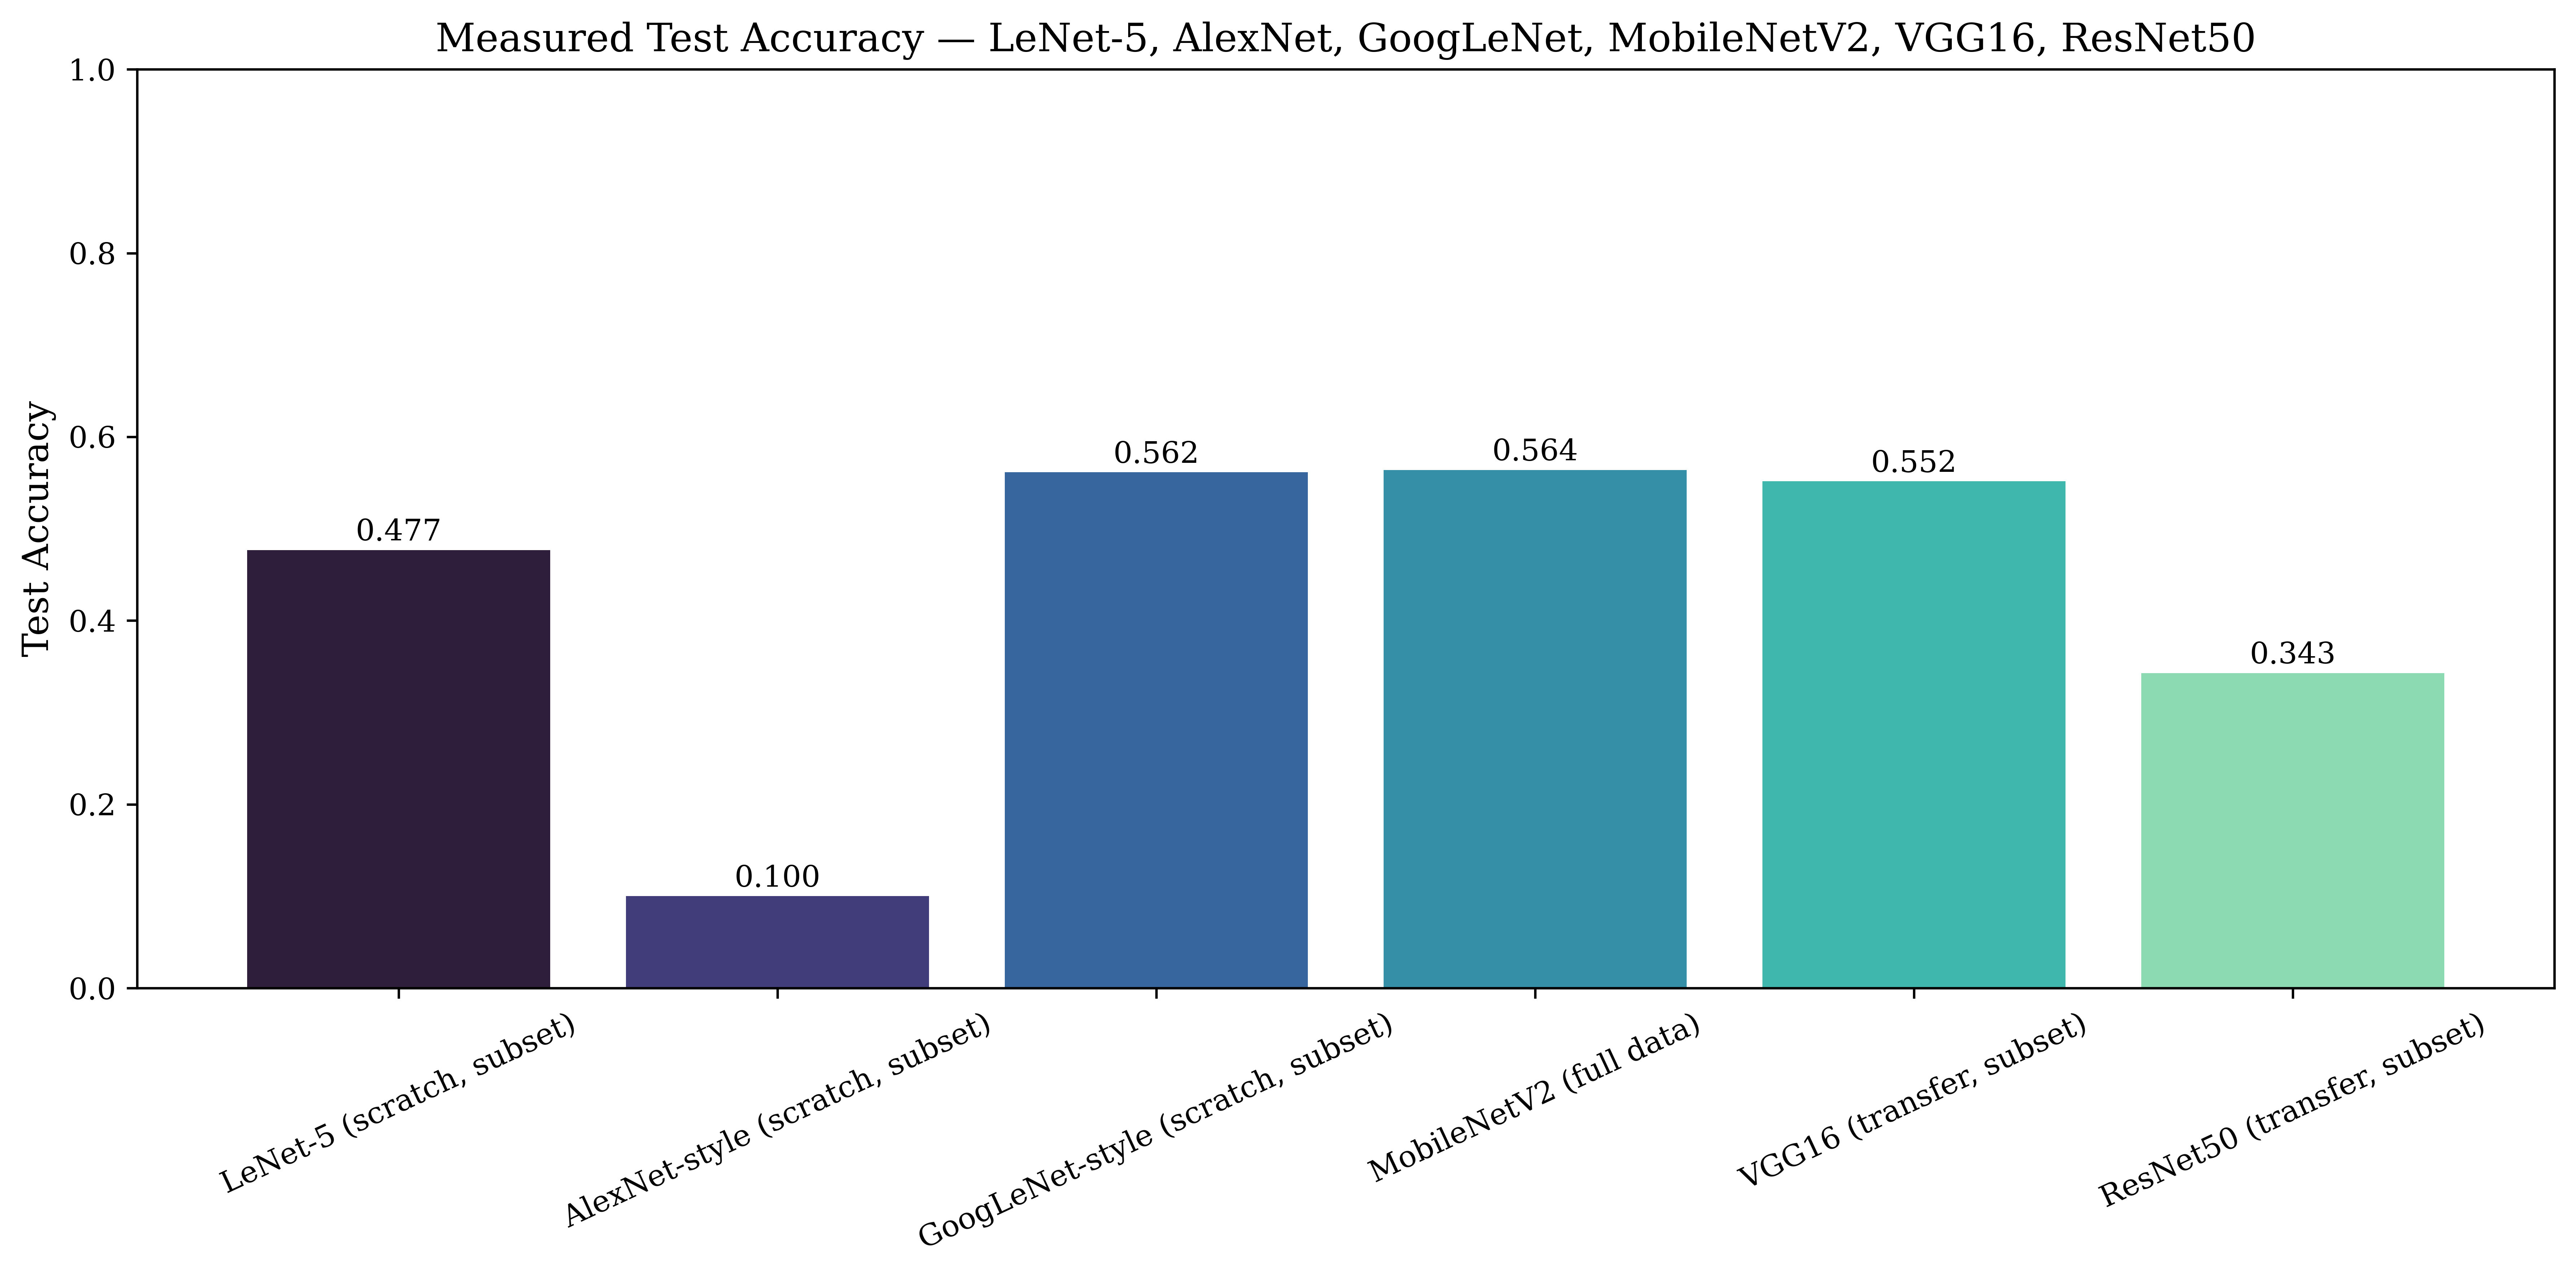

In [ ]:
# ===== CELL 24: Final measured comparison (Additional Exercise 6) =====
# NOTE: MobileNetV2 was trained on the full 50,000-image training set (Tasks 3-4).
# The other models were trained on the 8,000-image subset to save time, so parameter
# count and architecture are directly comparable but training-set size is not identical.

comparison_rows = [
    ("LeNet-5 (scratch, subset)",
     lenet5_params, lenet5_test_acc, lenet5_train_time),

    ("AlexNet-style (scratch, subset)",
     alexnet_params, alexnet_test_acc, alexnet_train_time),

    ("GoogLeNet-style (scratch, subset)",
     googlenet_params, googlenet_test_acc, googlenet_train_time),

    ("MobileNetV2 (full data)",
     total_params, test_acc,
     frozen_train_time + finetune_train_time),

    ("VGG16 (transfer, subset)",
     vgg16_params, vgg16_test_acc, vgg16_train_time),

    ("ResNet50 (transfer, subset)",
     resnet50_params, resnet50_test_acc, resnet50_train_time),
]

# Create formatted comparison table
lines = [
    f"{'Model':38s}"
    f"{'Parameters':>15s}"
    f"{'Test Accuracy':>16s}"
    f"{'Train Time (s)':>16s}"
]

for name, params, acc, t in comparison_rows:
    lines.append(
        f"{name:38s}"
        f"{params:>15,}"
        f"{acc:>16.4f}"
        f"{t:>16.1f}"
    )

comparison_text = "\n".join(lines)

print(comparison_text)


# Save measured comparison table
with open(
    os.path.join(PLOT_DIR, "14_architecture_comparison_measured.txt"),
    "w"
) as f:
    f.write(comparison_text)


# Create comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

names = [r[0] for r in comparison_rows]
accs = [r[2] for r in comparison_rows]

bars = ax.bar(
    names,
    accs,
    color=sns.color_palette("mako", len(names))
)

ax.set_ylabel("Test Accuracy")

ax.set_title(
    "Measured Test Accuracy — "
    "LeNet-5, AlexNet, GoogLeNet, MobileNetV2, VGG16, ResNet50"
)

ax.set_ylim(0, 1)

ax.tick_params(
    axis="x",
    rotation=25
)

# Display accuracy values above bars
for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f"{b.get_height():.3f}",
        ha="center"
    )

fig.tight_layout()

save_plot(fig, "15_architecture_comparison_chart")

plt.show()

In [ ]:
# ## Package All Figures & Reports (600 dpi EPS) for Your LaTeX Report

# ===== CELL 25: Zip and download all plots/reports =====
import shutil
from google.colab import files

zip_path = "/content/cnn_transfer_learning_lab_outputs"
shutil.make_archive(zip_path, 'zip', PLOT_DIR)

print("Files in archive:")
for f in sorted(os.listdir(PLOT_DIR)):
    print(" -", f)

files.download(zip_path + ".zip")


Files in archive:
 - 01_sample_images.eps
 - 02_training_accuracy.eps
 - 03_validation_accuracy.eps
 - 04_training_loss.eps
 - 05_validation_loss.eps
 - 06_finetune_comparison.eps
 - 07_classification_report.txt
 - 08_confusion_matrix.eps
 - 09_misclassified_images.eps
 - 10_hyperparameter_study.eps
 - 11_hyperparameter_results.txt
 - 12_performance_metrics.txt
 - 13_architecture_comparison.txt
 - 14_architecture_comparison_measured.txt
 - 15_architecture_comparison_chart.eps


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>